### Import

In [1]:
import os
import gc
import time
import pickle 
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
import matplotlib.ticker as ticker
from matplotlib import pyplot as plt 

from typing import Dict
from typing import Callable
from collections import defaultdict
from plot_metric.functions import BinaryClassification

import statsmodels.api as sm
from scipy.stats import spearmanr

from pynvml import *
import GPUtil
from threading import Thread

from sklearn.metrics import auc
from sklearn.metrics import f1_score 
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from aequitas.bias import Bias
from aequitas.group import Group
from aequitas.plotting import Plot
from aequitas.fairness import Fairness

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data.sampler import WeightedRandomSampler

from torch.nn.utils.rnn import pad_packed_sequence
from torch.nn.utils.rnn import pack_padded_sequence

from torch.optim import AdamW
from transformers import get_scheduler
from transformers import get_linear_schedule_with_warmup

from captum.attr import IntegratedGradients

pd.set_option('display.max_columns', 500)

### General parameters

In [2]:
path_data  = "./covid/Data/EHR/"
best_model = "./covid/checkpoints/"
race_path  = "Extraction/MIMICIV(V3)/Data/csvExtract/"

### Reading Data

In [3]:
train_df = pd.read_parquet(path_data + 'mimic.parquet' , engine='pyarrow')
train_df.head(2)

In [4]:
print(train_df.stay_id.nunique())
print(train_df.shape)

123487
(2842629, 257)


In [5]:
test_df = pd.read_parquet(path_data + 'covid.parquet' , engine='pyarrow')
test_df.head(2)

In [6]:
print(test_df.stay_id.nunique())
print(test_df.shape)

10561
(240003, 257)


### Select Cohort with 24 Hours ICU-stays

In [7]:
test_df_id = test_df[test_df.Bins >= 22].stay_id.unique()
test_df = test_df[test_df.stay_id.isin(test_df_id)].copy()

### Shared Variables 

In [8]:
continuse_col = ['Heart Rate', 'SpO2', 'SvO2', 'Oxygen Saturation', 'Respiratory Rate', 
                 'Respiratory Rate (Total)', 'Respiratory Rate (Set)', 'Temperature', 
                 'Non Invasive Blood Pressure mean', 'Non Invasive Blood Pressure systolic', 
                 'Non Invasive Blood Pressure diastolic', 'Arterial Blood Pressure mean', 
                 'Arterial Blood Pressure systolic', 'Arterial Blood Pressure diastolic',

                 'Glucose', 'Creatinine', 'Base Excess', 'BUN', 'Anion Gap', 
                 'Bicarbonate',  'Lactate', 'Lactate Dehydrogenase(LDH)', 'Hemoglobin', 'Hematocrit', 'pH', 
                 'Bilirubin, Direct', 'Bilirubin, Indirect', 'Bilirubin, Total', 'pO2', 'pCO2', 'PT', 'PTT', 
                 'INR(PT)', 'AST', 'ALT', 'RBC', 'RDW', 'White Blood Cells', 'Red Blood Cells', 
                 'Platelet Count', 'MCV', 'MCH', 'MCHC', 'Potassium', 'Sodium', 'Chloride', 'Magnesium', 
                 'Phosphate', 'Alkaline Phosphate', 'Ionized Calcium', 'Calcium non-ionized', 'Calcium, Total', 
                 'Protein', 'Total Protein', 'Cholesterol, Total', 'Differential-Bands', 'Differential-Monos', 
                 'Differential-Lymphs', 'Differential-Eos', 'Differential-Basos', 'Differential-Neuts', 'Oxygen', 
                 'O2 Flow', 'Total CO2', 'Flow Rate (L/min)', 'Mean Airway Pressure', 
                 'Plateau Pressure', 'Central Venous Pressure', 'Amylase', 'Albumin', 'Fibrinogen', 'Triglyceride',
                 'Transferrin', 'Ferritin', 'Troponin T', 'Vancomycin (Trough)', 'Vancomycin (Random)', 
                 'C-Reactive Protein (CRP)', 'FiO2', 'PEEP',  'PEEP (Set)', 'Tidal Volume',
                 'Tidal Volume (Set)', 'Ventilation Rate', 

                'UrineOutput_IO', 'Mg-nonIV_IO', 'Insulin_IO', 'K-IV_IO', 'Propofol_IO', 'Heparin_IO', 
                'Vasopressors_IO', 'Fentanyl_IO', 'Crystalloids_IO', 'Vancomycin_IO', 'P.O._IO', 'Dextrose_IO',]

categorical_col = ['Skin Temperature', 'Total GCS', 'GCS - Eye Opening', 'GCS - Verbal Response', 
                   'GCS - Motor Response', 'Richmond-RAS Scale', 'Goal Richmond-RAS Scale', 'Pain Level',
                   'Microbio Test']

binary_col = ['Pain Present', 'Mental status', 'Risk for Falls', 'Delirium assessment', 'CAM-ICU MS Change', 
              'CAM-ICU Inattention', 'CAM-ICU Disorganized thinking', 'CAM-ICU RASS LOC', 'CAM-ICU Altered LOC',
              'Intubated', 'Blood Culture', 'Norepinephrine_PRC', 'Fentanyl_PRC', 'Antibiotic_PRC', 'Heparin_PRC', 
              'Insulin_PRC', 'Propofol_PRC', 'Phenylephrine_PRC', 'Vasopressin_PRC', 'Epinephrine_PRC', 
              'Pantoprazole_PRC']

risk_scores = ['PaO2/FiO2', 'SIRS', 'Shock_Index', 'SOFA', 'SAPSII', 'OASIS']

static_col = ['age', 'gender', 'race_bit_0', 'race_bit_1', 'race_bit_2', 'Weight', 'Height']

### Imputation

In [9]:
def Imputation(train_df, test_df, continuse_col, categorical_col, binary_col, risk_scores):
    
    train_df['Weight'] = train_df.groupby(['stay_id'])['Weight'].transform('mean') 
    test_df[ 'Weight'] = test_df.groupby( ['stay_id'])['Weight'].transform('mean') 
    train_df['Height'] = train_df.groupby(['stay_id'])['Height'].transform('mean') 
    test_df[ 'Height'] = test_df.groupby( ['stay_id'])['Height'].transform('mean') 
    test_df[ 'Weight'].fillna((train_df['Weight'].mean()), inplace=True)
    train_df['Weight'].fillna((train_df['Weight'].mean()), inplace=True)
    test_df[ 'Height'].fillna((train_df['Height'].mean()), inplace=True)
    train_df['Height'].fillna((train_df['Height'].mean()), inplace=True)
    
    for i in sorted(continuse_col):
        test_df[ i].fillna((train_df[i].mean()), inplace=True)
        train_df[i].fillna((train_df[i].mean()), inplace=True)
    
    for i in categorical_col:
        test_df[ i].fillna((train_df[i].mode()[0]), inplace=True)
        train_df[i].fillna((train_df[i].mode()[0]), inplace=True)
            
    for i in sorted(binary_col):
        train_df[i].fillna(0, inplace=True)
        test_df[ i].fillna(0, inplace=True)
        
    for i in sorted(risk_scores):
        test_df[ i].fillna((train_df[i].mean()), inplace=True)
        train_df[i].fillna((train_df[i].mean()), inplace=True)
        
    train_df = train_df.round(2)
    test_df  = test_df.round(2)
            
    return train_df, test_df

In [10]:
train_df, test_df = Imputation(train_df, test_df, continuse_col, categorical_col, binary_col, risk_scores)

### Column Order

In [11]:
def order_columns(train_df, static_col, continuse_col, categorical_col, risk_scores, binary_col, 
                  use_diff=False,use_tslm=False):
    
    columns = []
    
    columns.extend(static_col)
    
    column_order = []
    column_order.extend(continuse_col)
    column_order.extend(categorical_col)

    for i in column_order:

        columns.append(i)

        temp_col = i + '_ind'
        if temp_col in list(train_df.columns):
            columns.append(temp_col)
            
        if use_diff:
            temp_col = i + '_diff'
            if temp_col in list(train_df.columns):
                columns.append(temp_col)
        if use_tslm:    
            temp_col = i + '_tslm'
            if temp_col in list(train_df.columns):
                columns.append(temp_col)

    columns.extend(risk_scores)
    columns.extend(binary_col)
    
    return columns

In [12]:
columns = order_columns(train_df, static_col, continuse_col, categorical_col, risk_scores, binary_col)

In [13]:
train_df.sort_values(by=['stay_id', 'Bins'], inplace=True)
test_df.sort_values( by=['stay_id', 'Bins'], inplace=True)

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

### Prepare Test Result Frame

In [14]:
label = 'icu_expire_flag'

In [15]:
def test_result_frame(test_data, columns, label):
        
    test_result = test_data.groupby(['stay_id'])[['stay_id', 'gender', 'age', label]].head(1).copy()
    
    test_result['ICU_FLAG'] = np.nan
    test_result.loc[test_result['icu_expire_flag'] == 0, 'ICU_FLAG'] = 'Survived'
    test_result.loc[test_result['icu_expire_flag'] == 1, 'ICU_FLAG'] = 'Dead'
    
    return test_result

In [16]:
test_result = test_result_frame(test_df, columns, label)

### Normalization

In [17]:
def Normalizing(train_df, test_df, continuse_col, categorical_col, risk_scores, static_col):
    
    norm = sorted(continuse_col + categorical_col + risk_scores + static_col)
    
    train_val = train_df[norm]
    test_val  = test_df[norm]

    scaler = MinMaxScaler().fit(train_val.values)

    train_normalized = scaler.transform(train_val.values)
    test_normalized  = scaler.transform(test_val.values)

    train_df[norm] = train_normalized
    test_df[norm]  = test_normalized

    train_df = train_df.round(2)
    test_df  = test_df.round(2)
    
    return train_df, test_df

In [18]:
train_df, test_df = Normalizing(train_df, test_df, continuse_col, categorical_col, risk_scores, static_col)

### Data Preparation

In [19]:
def data_model_ready(train_df, test_df, columns, label):
    
    train_data = train_df.groupby(['stay_id'])
    test_data  = test_df.groupby(['stay_id'])
    
    X_train = []
    y_train = []
    for _, frame in train_data:
        X_train.append(frame[columns].values)
        y_train.append(frame.iloc[0][label])
        
    X_test = []
    y_test = []
    for _, frame in test_data:
        X_test.append(frame[columns].values)
        y_test.append(frame.iloc[0][label])
        
    y_train = np.array(y_train)
    y_test  = np.array(y_test)
        
    pos_tr = y_train[y_train == 1]
    neg_tr = y_train[y_train == 0]
    print('Train= Positive - Negative: ', len(pos_tr), len(neg_tr))
    
    pos_ts = y_test[y_test == 1]
    neg_ts = y_test[y_test == 0]
    print('Test = Positive - Negative: ', len(pos_ts), len(neg_ts))
    
    return X_train, y_train, X_test, y_test

In [20]:
X_train, y_train, X_test, y_test = data_model_ready(train_df, test_df, columns, label)

<ipython-input>:8: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for _, frame in train_data:
<ipython-input>:14: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for _, frame in test_data:


Train= Positive - Negative:  9292 114195
Test = Positive - Negative:  737 8357


### Padding

In [21]:
observation_window = 24

In [22]:
def padd(data, max_len):
    
    padded_data = []
    length = []
    
    for item in data:
        tmp = np.zeros((max_len, item.shape[1]))
        
        if item.shape[0] > max_len :
            tmp[:max_len, :item.shape[1]] = item[(item.shape[0] - max_len):, :item.shape[1]]
            length.append(max_len)
            
        else:
            tmp[:item.shape[0], :item.shape[1]] = item
            length.append(item.shape[0])
        
        padded_data.append(tmp)
        
    padded_data = np.array(padded_data)
    length = np.array(length)
    
    return padded_data, length

In [23]:
X_data_train, X_len_train = padd(X_train, observation_window)
X_data_test,  X_len_test  = padd(X_test , observation_window)

### Plots

In [24]:
def plot_losses(train_losses, valid_losses):
    
    fig = plt.figure(figsize=(10, 5))

    plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-o', label='Training Loss'  , linewidth=2, markersize=5)
    plt.plot(range(1, len(valid_losses) + 1), valid_losses, 'g-s', label='Validation Loss', linewidth=2, markersize=5)

    minposs = valid_losses.index(min(valid_losses)) + 1 
    plt.axvline(minposs, linestyle='--', color='r', linewidth=2, label='Early Stopping Checkpoint')

    plt.xlabel('Epochs', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.title('Training and Validation Loss by Epoch', fontsize=16)
    plt.ylim(0, 1.5)  
    plt.xlim(0, len(train_losses) + 1)

    plt.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray')
    plt.legend(fontsize=12)
    plt.tight_layout()

    ax = plt.gca() 
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) 
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()

In [25]:
def ROC_curve(true_label, prediction_prob):
    
    AUC = roc_auc_score(true_label, prediction_prob)
    fpr, tpr, roc_thresholds = roc_curve(true_label, prediction_prob)

    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    plt.plot(fpr, tpr, color='darkorange', lw=1.2, label='Model (AUC = {:.2f})'.format(AUC))
    plt.plot([0, 1], [0, 1], color='navy', lw=1.2, linestyle='--', label='Random (AUC = 0.50)')
    plt.xlim([-0.01, 1.00])
    plt.ylim([ 0.00, 1.02])
    plt.xlabel('False Positive Rate', fontsize=8)
    plt.ylabel('True Positive Rate', fontsize=8)
    plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [26]:
def PRC_REC_curve(true_label, prediction_prob):
    
    AP = average_precision_score(true_label, prediction_prob)
    precision, recall, pr_thresholds = precision_recall_curve(true_label, prediction_prob)
    no_skill = len(true_label[true_label == 1]) / len(true_label) 

    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    plt.plot(recall, precision, color='darkorange', lw=1.2, label='Model (AP = {:.2f})'.format(AP))
    plt.plot([0, 1], [no_skill, no_skill], color='navy', lw=1.2, linestyle='--', label='No Skill (AP = {:.2f})'.format(no_skill))
    plt.xlim([-0.01, 1.00])
    plt.ylim([ 0.00, 1.02])
    plt.xlabel('Recall', fontsize=8)
    plt.ylabel('Precision', fontsize=8)
    plt.title('Precision-Recall Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [27]:
def Calibration_curve(true_label, prediction_prob):
    
    fig, ax = plt.subplots(figsize=(5, 2.5), dpi=120)
    
    frac_of_pos, mean_pred_value = calibration_curve(true_label, prediction_prob, n_bins=10)

    plt.plot([0, 1], [0, 1], "--", label="Perfectly Calibrated", color='navy', lw=1.3)
    plt.plot(mean_pred_value, frac_of_pos, "*-", label='Model Calibration', lw=1.2, color='darkorange')

    plt.ylabel("Fraction of Positives", fontsize=8)
    plt.xlabel("Mean Predicted Value", fontsize=8)
    plt.ylim([-0.05, 1.05])
    plt.xlim([-0.05, 1.05])
    plt.title('Calibration Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [28]:
def Confusion_Matrix(true_label, predicted_label, classes, cmap=plt.cm.OrRd):
    
    cm = confusion_matrix(true_label, predicted_label, labels=[1, 0])

    plt.figure(figsize = (5, 5))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title('Confusion Matrix', size = 14)
    plt.colorbar(aspect=4)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=40, size = 14)
    plt.yticks(tick_marks, classes, size = 14)

    fmt = 'd'
    thresh = cm.max() / 2.
    
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), fontsize = 14,
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
        
    plt.tight_layout()
    plt.ylabel('True Label', size = 13)
    plt.xlabel('Predicted Label', size = 13)
    plt.show()

### Performance

In [29]:
def Prediction_Labels_Thresholding(true_label, prediction_prob, decision_recall):
    
    precision, recall, pr_thresholds = precision_recall_curve(true_label, prediction_prob, pos_label=1)
    
    index = np.argwhere(recall >= decision_recall)[-1][0]
    decision_threshold = pr_thresholds[index]
    predicted_label = (np.array(prediction_prob) > decision_threshold).astype(int)
    
    print("Decision Threshold is: ", np.round(decision_threshold, 2))
    
    return predicted_label, decision_threshold

In [30]:
def Performance_Metrics(true_label, predicted_label, prediction_prob):
    
    TN, FP, FN, TP = confusion_matrix(true_label, predicted_label).ravel()

    ACC = (TP+TN)/(TP+FP+FN+TN)
    PRC = TP/(TP+FP)
    REC = TP/(TP+FN)
    F1M = (2*PRC*REC)/(PRC+REC)
    PPV = TP/(TP+FP)
    NPV = TN/(TN+FN)
    SEN = TP/(TP+FN)
    SPE = TN/(TN+FP) 
    FPR = FP/(FP+TN)
    FNR = FN/(TP+FN)
    FDR = FP/(TP+FP)

    AUC = roc_auc_score(true_label, prediction_prob)
    AP  = average_precision_score(true_label, prediction_prob)
    MCC = matthews_corrcoef(true_label, predicted_label)
    
    print("ACC = " , np.round(ACC, 2)), print("PRC = " , np.round(PRC, 2))
    print("REC = " , np.round(REC, 2)), print("F1M = " , np.round(F1M, 2))
    print("PPV = " , np.round(PPV, 2)), print("NPV = " , np.round(NPV, 2))
    print("SEN = " , np.round(SEN, 2)), print("SPE = " , np.round(SPE, 2))
    print("FPR = " , np.round(FPR, 2)), print("FNR = " , np.round(FNR, 2))
    print("FDR = " , np.round(FDR, 2)), print("AUC = " , np.round(AUC, 2))
    print("AP  = " , np.round(AP,  2)), print("MCC = " , np.round(MCC, 2))

In [31]:
def performance_metric(true_labels, pred_probs):
    
    precision, recall, pr_thresholds = precision_recall_curve(true_labels, pred_probs)
    decision_recall = 0.8
    index = np.argwhere(recall >= decision_recall)[-1][0]
    decision_threshold = pr_thresholds[index]
    predicted_label = (np.array(pred_probs) > decision_threshold).astype(int)

    acc = accuracy_score(true_labels, predicted_label)
    auc = roc_auc_score(true_labels, pred_probs)
    f1  = f1_score(true_labels, predicted_label)
    precision = precision_score(true_labels, predicted_label)
    recall = recall_score(true_labels, predicted_label)
    pr_auc = average_precision_score(true_labels, pred_probs)
    ppv = precision  
    npv = precision_score(true_labels, predicted_label, pos_label=0) 
    mcc = matthews_corrcoef(true_labels, predicted_label)
    
    metrics = {'ACC': np.round(acc, 2),
               'PRC': np.round(precision, 2),
               'REC': np.round(recall, 2),
               'F1M': np.round(f1, 2),
               'PPV': np.round(ppv, 2),
               'NPV': np.round(npv, 2),
               'AUC': np.round(auc, 2),
               'AP': np.round(pr_auc, 2),
               'MCC': np.round(mcc, 2),
               'THRSH':np.round(decision_threshold, 2)
              }
    
    return metrics

In [32]:
def Binary_Classification_Performance(true_label, prediction_prob, threshold):
    
    bc_all = BinaryClassification(true_label, prediction_prob, labels=["Negative", "Positive"])
    roc_auc = roc_auc_score(true_label, prediction_prob)
    precision, recall, _ = precision_recall_curve(true_label, prediction_prob)
    pr_auc = auc(recall, precision)
    
    print('ROC AUC: ', np.round(roc_auc, 2))
    print('PR  AUC: ', np.round(pr_auc , 2))
    
    print(bc_all.print_report(threshold= threshold))
    
    plt.figure(figsize=(12,8))

    plt.subplot2grid((2,6), (0,0), colspan=2)
    bc_all.plot_threshold( threshold= threshold, title= 'Precision, Recall, F-1', annotation= False,
                           c_recall_line= 'darkred', lw_recall_line= 1.5, ls_recall_line= '-',
                           c_prec_line= 'darkgreen', lw_prec_line= 1.5, ls_prec_line= '-',
                           c_fscr_line= 'navy', lw_fscr_line= 1.5, ls_fscr_line= '-',
                           c_thresh_line= 'gray', lw_thresh_line= 1.5, ls_thresh_line= '--',
                           c_bestthresh_line= 'black', lw_bestthresh_line= 1.5, ls_bestthresh_line= ':')

    plt.subplot2grid((2,6), (0,2), colspan=2)
    bc_all.plot_roc_curve(threshold= threshold, plot_threshold= True, linewidth= 1.5, y_text_margin= 0.05, 
                          x_text_margin= 0.5, c_roc_curve= 'black', c_random_guess= 'gray', c_thresh_lines= 'gray', 
                          ls_roc_curve= '-', ls_thresh_lines= ':', ls_random_guess= '--', 
                          title= 'Receiver Operating Characteristic', loc_legend= 'lower right')

    plt.subplot2grid((2,6), (0,4), colspan=2)
    bc_all.plot_precision_recall_curve(threshold= threshold, plot_threshold= True, beta= 1, linewidth= 1.5, 
                                       fscore_iso= None, iso_alpha= 0.7, y_text_margin= 0.03, x_text_margin= 0.5, 
                                       c_pr_curve= 'black', c_mean_prec= 'gray', c_f1_iso= 'grey', 
                                       c_thresh_point= 'darkred', ls_pr_curve= '-', ls_mean_prec= '--', 
                                       ls_thresh= ':', ls_fscore_iso= ':', marker_pr_curve= None)

    plt.subplot2grid((2,6), (1,0), colspan=2)
    bc_all.plot_confusion_matrix(threshold= 0.5)

    plt.subplot2grid((2,6), (1,2), colspan=2)
    bc_all.plot_confusion_matrix(threshold= 0.5, normalize=True)

    plt.subplot2grid((2,6), (1,4), colspan=2)
    bc_all.plot_class_distribution(threshold= threshold, display_prediction= True, alpha= 0.8, jitter= 0.25, 
                                   pal_colors= ["#00C853", "#FF8A80", "#C5E1A5", "#D50000"],
                                   display_violin= True, c_violin= 'white', strip_marker_size= 4, 
                                   strip_lw_edge= None, strip_c_edge= None, ls_thresh_line= ':', 
                                   c_thresh_line= 'black', lw_thresh_line= 2, title= None)

    plt.show()

### GPU Utilization

In [33]:
def print_gpu_utilization():
    
    nvmlInit()
    handle = nvmlDeviceGetHandleByIndex(0)
    info   = nvmlDeviceGetMemoryInfo(handle)
    print(f"GPU memory occupied: {info.used//1024**2} MB.")
    
class Monitor(Thread):
    
    def __init__(self, delay):
        super(Monitor, self).__init__()
        self.stopped = False
        self.delay = delay
        self.start()

    def run(self):
        while not self.stopped:
            GPUtil.showUtilization()
            for _ in range(10):  
                time.sleep(self.delay / 10)
                if self.stopped:
                    break

    def stop(self):
        self.stopped = True

### LSTM Model

In [34]:
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(42)

### Hyperparameters

In [35]:
lstm_input_size  = len(columns)
lstm_hidden_size = 256
lstm_num_layers  = 1
lstm_drop_out = 0.0

number_classes = 2
num_epochs = 20
batch_size = 16

patience = 10
file_name = 'LSTM_checkpoint.pt'

### Device

In [36]:
device = "cuda" if torch.cuda.is_available() else "cpu"
kwargs = {'num_workers': 1, 'pin_memory': True} if device=='cuda' else {}

### Dataset 

In [37]:
class Data(Dataset):
    
    def __init__(self, X, y, l):
        
        self.X = torch.FloatTensor(X.astype('float'))
        self.y = torch.FloatTensor(y.astype('float'))
        self.l = l
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        
        X = self.X[index]
        y = self.y[index]
        l = self.l[index]
        
        return X, y, l

In [38]:
train_dataset = Data(X_data_train, y_train, X_len_train)
test_dataset  = Data(X_data_test , y_test , X_len_test)

### Random Sampling

In [39]:
def class_sampler_A(y_train):
    
    train_class_sample_count = torch.tensor([(torch.tensor(y_train) == t).sum() for t in torch.unique(torch.tensor(y_train), sorted=True)])
    train_weight = 1 / train_class_sample_count.float()
    train_samples_weight = torch.tensor([train_weight[i] for i in torch.tensor(y_train).long()])
    train_sampler = WeightedRandomSampler(train_samples_weight, len(train_samples_weight))
    
    return train_sampler

In [40]:
def class_sampler_B(y_train):
    
    class_counts   = [len(y_train) - sum(y_train), sum(y_train)]
    class_weights  = [sum(y_train) / len(y_train), (len(y_train) - sum(y_train)) / len(y_train)]
    sample_weights = [class_weights[int(y)] for y in y_train]
    train_sampler  = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    
    return train_sampler

In [41]:
train_sampler = class_sampler_B(y_train)

### Dataloader

In [42]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, **kwargs)
test_loader  = DataLoader(test_dataset , batch_size=batch_size, shuffle=False, **kwargs)

### LSTM Model

In [43]:
class RNN(nn.Module):
    
    def __init__(self, lstm_input_size, lstm_hidden_size, lstm_num_layers, drop_out, num_classes):
        
        super(RNN, self).__init__()
        
        self.lstm_input_size  = lstm_input_size
        self.lstm_hidden_size = lstm_hidden_size
        self.lstm_num_layers  = lstm_num_layers
        
        self.lstm = nn.LSTM(self.lstm_input_size, 
                            self.lstm_hidden_size, 
                            self.lstm_num_layers, 
                            batch_first=True, 
                            bidirectional=True)
        
        self.classification_head = nn.Sequential(nn.Linear(self.lstm_hidden_size*2, 32),
                                                 nn.ReLU(),
                                                 nn.Dropout(drop_out),
                                                 nn.Linear(32, num_classes))
        
    def forward(self, x, seq_lengths):
        
        packed_input = pack_padded_sequence(x, seq_lengths, batch_first=True, enforce_sorted=False)
        out, (h, c) = self.lstm(packed_input)
        
        h_forward  = h[-2, :, :]
        h_backward = h[-1, :, :]
        lstm_out = torch.cat((h_forward, h_backward), dim=1)
        
        output = self.classification_head(lstm_out)

        return output

In [44]:
model = RNN(lstm_input_size, lstm_hidden_size, lstm_num_layers, lstm_drop_out, number_classes)
model = model.to(device)

### Weight Initialization

In [45]:
def weight_init(m):
    
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight.data)
        nn.init.normal_(m.bias.data)
        
    elif isinstance(m, nn.LSTM):
        for param in m.parameters():
            if len(param.shape) >= 2:
                nn.init.xavier_uniform_(param.data)
            else:
                nn.init.normal_(param.data)
                
    elif isinstance(m, nn.GRU):
        for param in m.parameters():
            if len(param.shape) >= 2:
                nn.init.xavier_uniform_(param.data)
            else:
                nn.init.normal_(param.data)

In [46]:
model.apply(weight_init)

RNN(
  (lstm): LSTM(244, 256, batch_first=True, bidirectional=True)
  (classification_head): Sequential(
    (0): Linear(in_features=512, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=32, out_features=2, bias=True)
  )
)

### Loss Function

In [47]:
class_weight = torch.Tensor([0.25, 0.7])
class_weight = class_weight.to(device)

criterion = nn.CrossEntropyLoss(weight= class_weight)

### Optimizer & Scheduler

In [48]:
learning_rate = 0.0005

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [49]:
# learning_rate = 0.00005

# num_training_steps = 100 * len(train_loader)
# num_warmup_steps   = num_training_steps // 10

# optimizer = AdamW(model.parameters(), lr=learning_rate)

# scheduler = get_scheduler("linear", 
#                           optimizer= optimizer, 
#                           num_warmup_steps= num_warmup_steps, 
#                           num_training_steps= num_training_steps)

### EarlyStopping 

In [50]:
class EarlyStopping:
    
    def __init__(self, patience: int = 7, verbose: bool = False, 
                 deltas: Dict[str, float] = {'auc': 0.0, 'f1': 0.0},
                 path: str = './Output/', file_name: str = 'checkpoint.pt', trace_func: Callable = print):

        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_scores = {'auc': -np.inf, 'f1': -np.inf}
        self.early_stop = False
        self.deltas = deltas
        self.path = path
        self.file_name = file_name
        self.trace_func = trace_func

    def __call__(self, metrics: Dict[str, float], model):

        if self._check_improvement(metrics):
            self.best_scores.update({metric: metrics[metric] for metric in self.best_scores.keys()})
            self.counter = 0
            self.save_checkpoint(metrics, model)
        else:
            self.counter += 1
            self.trace_func(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True

    def _check_improvement(self, metrics: Dict[str, float]) -> bool:

        return any(metrics[metric] > self.best_scores[metric] + self.deltas[metric] for metric in self.best_scores)

    def save_checkpoint(self, metrics: Dict[str, float], model):
        
         if self.verbose:
            self.trace_func(
                f'Metrics improved - AUC: {metrics["auc"]:.6f}, F1: {metrics["f1"]:.6f}. Saving model ...')
        
        torch.save(model.state_dict(), os.path.join(self.path, self.file_name))

In [51]:
early_stopping = EarlyStopping(patience=patience, verbose=True, path=best_model, file_name=file_name)

### Validation

In [52]:
def evaluate(dataloader, epoch):
    
    model.eval()
    loss_accumulator = 0
    
    labels = []
    predictions = []
        
    with torch.no_grad():
    
        for x, y, l in dataloader:

            x = x.to(device)
            y = y.to(device)
            l = l.cpu()
            y = y.long()

            seq_lengths, perm_idx = l.sort(0, descending=True)
            x = x[perm_idx]
            y = y[perm_idx]

            outputs = model(x, seq_lengths)
            entropy_loss = criterion(outputs, y)

            loss = entropy_loss.item()
            loss_accumulator += loss

            prediction = nn.Softmax(dim=1)(outputs)
            prediction = prediction.detach().cpu().numpy()
            prediction = prediction[:,1]

            label = y.detach().cpu().numpy()

            labels.extend(label)
            predictions.extend(prediction)
            

        epoch_loss = loss_accumulator / len(dataloader)

        labels = np.array(labels)
        predictions = np.array(predictions)
        
        decision_recall = 0.8
        predicted_labels, decision_threshold = Prediction_Labels_Thresholding(labels, 
                                                                              predictions, 
                                                                              decision_recall)

        auc = roc_auc_score(labels, predictions)
        f1  = f1_score(labels, predicted_labels)
        
        print(f"AUC: {np.round(auc, 3)}")
        print(f"F-1: {np.round(f1, 3)}")
        print_gpu_utilization()

    return epoch_loss, auc, f1

### Training

In [ ]:
train_losses = []
valid_losses = []

for epoch in range(num_epochs):
    
    if epoch%10 == 0:
        train_loader = DataLoader(train_dataset, batch_size=2*batch_size, shuffle=False, sampler=train_sampler, **kwargs)
    
    running_loss = 0
    
    model.train()
    for x, y, l in train_loader:
        
        x = x.to(device)
        y = y.to(device)
        l = l.cpu()
        y = y.long()
        
        seq_lengths, perm_idx = l.sort(0, descending=True)
        x = x[perm_idx]
        y = y[perm_idx]
        
        outputs = model(x, seq_lengths)
        entropy_loss = criterion(outputs, y)
        
        loss = entropy_loss 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()   
        running_loss += loss.item()  
        
    avg_train_loss = running_loss/len(train_loader)
    
    avg_valid_loss, avg_valid_auc, avg_valid_f1 = evaluate(test_loader, epoch)
                
    scheduler.step()
    
    train_losses.append(avg_train_loss)
    valid_losses.append(avg_valid_loss)

    print("Epoch: {}/{} ".format(epoch+1, num_epochs))
    print("Training Loss: {:.3f} ".format(np.round(avg_train_loss, 3)))
    print("Validation Loss: {:.3f} ".format(np.round(avg_valid_loss, 3)))
    print("***** ##### ******")
    
    check_loss = np.round(avg_valid_loss, 3)
    check_auc  = np.round(avg_valid_auc , 3)
    check_f1   = np.round(avg_valid_f1  , 3)
    check_metric = {'auc': check_auc, 'f1': check_f1}
    early_stopping(check_metric, model)

    if early_stopping.early_stop:
        print("Early stopping")
        break

### Training Loss

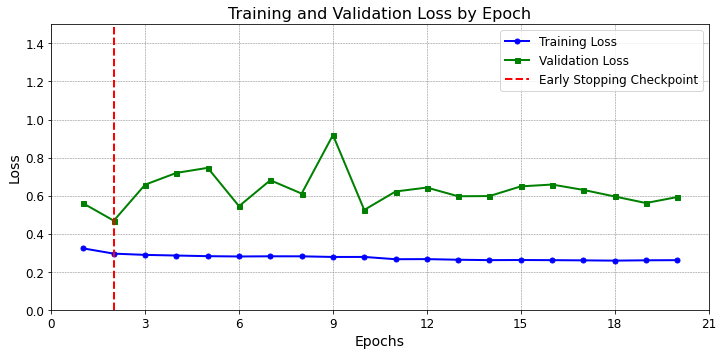

In [54]:
plot_losses(train_losses, valid_losses)

## Testing

### Load Best Model

In [55]:
model.load_state_dict(torch.load(best_model + file_name))

<All keys matched successfully>

### Test Loop

In [56]:
def test_model(model, dataloader):
    
    model.eval()

    with torch.no_grad():

        total = 0
        labels = []
        predictions = []

        for x, y, l in dataloader:

            x = x.to(device)
            y = y.to(device)
            l = l.cpu()
            y = y.long()

            outputs = model(x, l)
            prediction = nn.Softmax(dim=1)(outputs)
            prediction = prediction.detach().cpu().numpy()
            prediction = prediction[:,1]
            
            label = y.detach().cpu().numpy()

            labels.extend(label)
            predictions.extend(prediction)

        labels = np.array(labels)
        predictions = np.array(predictions)
    
    return labels, predictions

In [57]:
lstm_true_labels, lstm_prediction_probs = test_model(model, test_loader)

### Calibration

In [58]:
def calibrate_probabilities(predicted_probabilities, true_labels):

    predicted_probabilities = np.asarray(predicted_probabilities)
    true_labels = np.asarray(true_labels)

    isotonic_regressor = IsotonicRegression(out_of_bounds='clip')
    isotonic_regressor.fit(predicted_probabilities, true_labels)

    calibrated_probabilities = isotonic_regressor.transform(predicted_probabilities)

    return isotonic_regressor

In [59]:
# true_labels_train, pred_probs_train = test_model(model, train_loader)
# isotonic_regressor = calibrate_probabilities(pred_probs_train, true_labels_train)

# lstm_prediction_probs = isotonic_regressor.transform(lstm_prediction_probs)

### LSTM Result

In [60]:
test_result['LSTM_PREDICT_PROB'] = lstm_prediction_probs 
test_result['LSTM_LABEL'] = lstm_true_labels 

print(test_result[test_result.icu_expire_flag != test_result.LSTM_LABEL].shape)

(0, 7)


### ROC

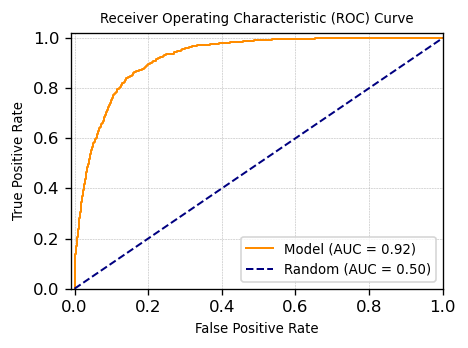

In [61]:
ROC_curve(test_result.icu_expire_flag, test_result.LSTM_PREDICT_PROB)

### Precision - Recall

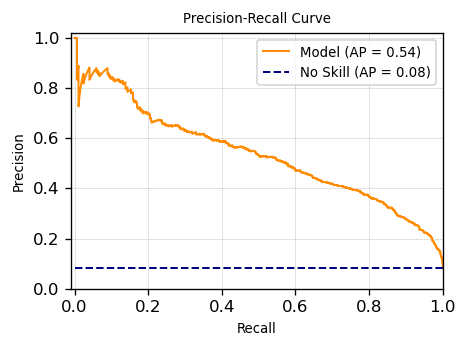

In [62]:
PRC_REC_curve(test_result.icu_expire_flag, test_result.LSTM_PREDICT_PROB)

### Calibration

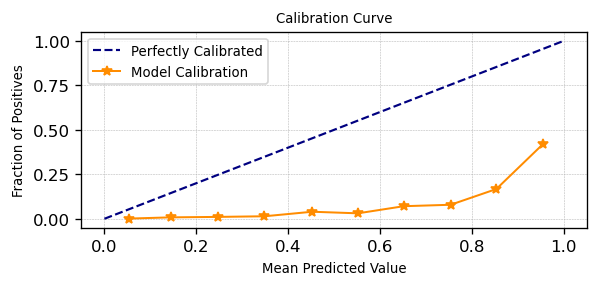

In [63]:
Calibration_curve(test_result.icu_expire_flag, test_result.LSTM_PREDICT_PROB)

### Set Decision Threshold

In [64]:
decision_recall = 0.8

In [65]:
predicted_label_lstm, decision_threshold_lstm = Prediction_Labels_Thresholding(lstm_true_labels, 
                                                                               lstm_prediction_probs, 
                                                                               decision_recall)

test_result['LSTM_PREDICT_LABEL'] = predicted_label_lstm

Decision Threshold is:  0.85


### Confusion Matrix

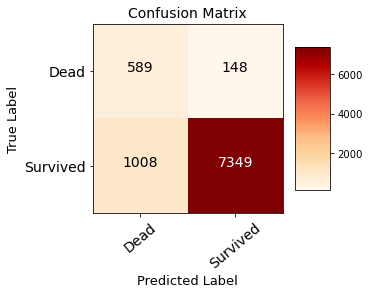

In [66]:
Confusion_Matrix(lstm_true_labels, predicted_label_lstm, classes = ['Dead', 'Survived'])

### Performance Metrics

In [67]:
Performance_Metrics(lstm_true_labels, predicted_label_lstm, lstm_prediction_probs)

ACC =  0.87
PRC =  0.37
REC =  0.8
F1M =  0.5
PPV =  0.37
NPV =  0.98
SEN =  0.8
SPE =  0.88
FPR =  0.12
FNR =  0.2
FDR =  0.63
AUC =  0.92
AP  =  0.54
MCC =  0.49


### Distribution of Prediction Probabilities

In [68]:
df_prediction_lstm_alive = test_result[test_result['ICU_FLAG'] == 'Survived']
df_prediction_lstm_dead  = test_result[test_result['ICU_FLAG'] == 'Dead']

### Alive Patients

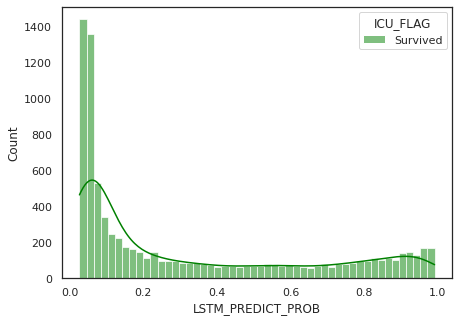

In [69]:
plt.figure(figsize=(7, 5))
sns.set(font_scale= 1)
sns.set_style(style='white')
sns.histplot(data=df_prediction_lstm_alive, x='LSTM_PREDICT_PROB', kde=True, stat='count', bins=50, fill=True,
             legend=True, hue='ICU_FLAG', palette=['green'])
plt.show()

### Dead Patients

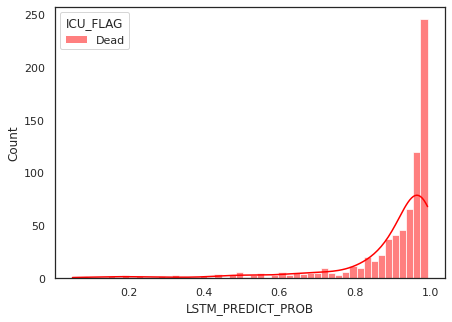

In [70]:
plt.figure(figsize=(7, 5))
sns.set(font_scale= 1)
sns.set_style(style='white')
sns.histplot(data=df_prediction_lstm_dead, x='LSTM_PREDICT_PROB', kde=True, stat='count', bins=50, fill=True,
             legend=True, hue='ICU_FLAG', palette=['red'])
plt.show()

### LSTM 

ROC AUC:  0.92
PR  AUC:  0.54
                   ________________________
                  |  Classification Report |
                   ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
              precision    recall  f1-score   support

    Negative       0.98      0.88      0.93      8357
    Positive       0.37      0.80      0.50       737

    accuracy                           0.87      9094
   macro avg       0.67      0.84      0.72      9094
weighted avg       0.93      0.87      0.89      9094

None


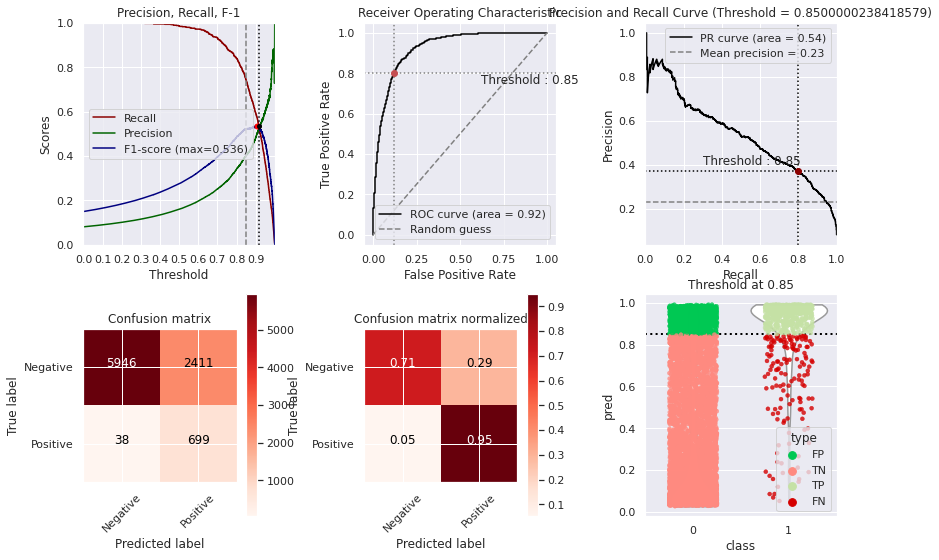

In [71]:
Binary_Classification_Performance(lstm_true_labels, lstm_prediction_probs, decision_threshold_lstm)

### Save Results

In [73]:
test_result = test_result.reset_index(drop=True)
test_result.to_csv("./Results/LSTM_Result.csv", index=False)
# test_result.to_csv("./Results/LSTM_Result_Cal.csv", index=False)

In [85]:
# test_result = pd.read_csv("./Results/LSTM_Result.csv")

### Bias & Fairness

In [86]:
test_result.head(3)

### Read Race Dictionary

In [137]:
df_demographics = pd.read_csv(path_data + 'demographic_all.csv')
df_demographics = df_demographics[['stay_id', 'race']]

In [138]:
test_result = test_result.merge(df_demographics, on='stay_id', how='left')

In [139]:
with open(race_path + 'race_dictionary.pkl', 'rb') as f:
    race_dictionary = pickle.load(f)

In [140]:
general_ethnicity_mapping = {
    
    'WHITE': 'White',
    'WHITE - RUSSIAN': 'White',
    'WHITE - BRAZILIAN': 'White',
    'WHITE - OTHER EUROPEAN': 'White',
    'WHITE - EASTERN EUROPEAN': 'White',
    'PORTUGUESE': 'White',
    
    'UNKNOWN': 'Other/Unknown',
    'UNABLE TO OBTAIN': 'Other/Unknown',
    'PATIENT DECLINED TO ANSWER': 'Other/Unknown',
    'OTHER': 'Other/Unknown',
    'MIDDLE EASTERN': 'Other/Unknown',
    'MULTIPLE RACE/ETHNICITY': 'Other/Unknown',
    'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER': 'Other/Unknown',
    'AMERICAN INDIAN/ALASKA NATIVE': 'Other/Unknown',
    
    'ASIAN': 'Asian',
    'ASIAN - CHINESE': 'Asian',
    'ASIAN - SOUTH EAST ASIAN': 'Asian',
    'ASIAN - KOREAN': 'Asian',
    'ASIAN - ASIAN INDIAN': 'Asian',
    
    'BLACK/AFRICAN': 'African American',
    'BLACK/CAPE VERDEAN': 'African American',
    'BLACK/AFRICAN AMERICAN': 'African American',
    'BLACK/CARIBBEAN ISLAND': 'African American',
    
    'SOUTH AMERICAN': 'Hispanic',
    'HISPANIC OR LATINO': 'Hispanic',
    'HISPANIC/LATINO - CUBAN': 'Hispanic',
    'HISPANIC/LATINO - MEXICAN': 'Hispanic',
    'HISPANIC/LATINO - HONDURAN': 'Hispanic',
    'HISPANIC/LATINO - COLUMBIAN': 'Hispanic',
    'HISPANIC/LATINO - DOMINICAN': 'Hispanic',
    'HISPANIC/LATINO - SALVADORAN': 'Hispanic',
    'HISPANIC/LATINO - GUATEMALAN': 'Hispanic',
    'HISPANIC/LATINO - PUERTO RICAN': 'Hispanic',
    'HISPANIC/LATINO - CENTRAL AMERICAN': 'Hispanic'}

In [120]:
general_ethnicity_mapping = {
    
    'WHITE': 'White',
    'WHITE - RUSSIAN': 'White',
    'WHITE - BRAZILIAN': 'White',
    'WHITE - OTHER EUROPEAN': 'White',
    'WHITE - EASTERN EUROPEAN': 'White',
    'PORTUGUESE': 'White',
    
    'UNKNOWN': 'Unknown',
    'UNABLE TO OBTAIN': 'Unknown',
    'PATIENT DECLINED TO ANSWER': 'Unknown',
    
    'OTHER': 'Other',
    'MIDDLE EASTERN': 'Other',
    'MULTIPLE RACE/ETHNICITY': 'Other',
    'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER': 'Other',
    
    'ASIAN': 'Asian',
    'ASIAN - CHINESE': 'Asian',
    'ASIAN - SOUTH EAST ASIAN': 'Asian',
    'ASIAN - KOREAN': 'Asian',
    'ASIAN - ASIAN INDIAN': 'Asian',
    
    'AMERICAN INDIAN/ALASKA NATIVE': 'Native American',
    
    'BLACK/AFRICAN': 'Black/African American',
    'BLACK/CAPE VERDEAN': 'Black/African American',
    'BLACK/AFRICAN AMERICAN': 'Black/African American',
    'BLACK/CARIBBEAN ISLAND': 'Black/African American',
    
    'SOUTH AMERICAN': 'Hispanic/Latino',
    'HISPANIC OR LATINO': 'Hispanic/Latino',
    'HISPANIC/LATINO - CUBAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - MEXICAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - HONDURAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - COLUMBIAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - DOMINICAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - SALVADORAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - GUATEMALAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - PUERTO RICAN': 'Hispanic/Latino',
    'HISPANIC/LATINO - CENTRAL AMERICAN': 'Hispanic/Latino'}

In [141]:
def replace_ethnicity_with_names(df, ethnicity_dict):
    
    inv_ethnicity_dict = {v: k for k, v in ethnicity_dict.items()}
    df['race'] = df['race'].map(inv_ethnicity_dict)
    
    return df

In [142]:
def categorize_ethnicity(df, new_mapping):
    
    df['race'] = df['race'].map(new_mapping)
    
    return df

In [143]:
demog_col = ['stay_id', 'gender', 'age', 'race']
df_demog = test_result[demog_col].copy()

df_demog = replace_ethnicity_with_names(df_demog, race_dictionary)
df_demog = categorize_ethnicity(df_demog, general_ethnicity_mapping)

df_demog = df_demog.drop_duplicates().reset_index(drop=True)
df_demog.loc[df_demog.gender == 1.0, 'gender'] = 'Male'
df_demog.loc[df_demog.gender == 2.0, 'gender'] = 'Female'

bins = [-np.inf, 35, 50, 60, 75, np.inf]
labels = ['Under 35', '36-50', '51-60', '61-75', 'Over 76']
df_demog['agegroup'] = pd.cut(df_demog['age'], bins=bins, labels=labels, right=False)
df_demog = df_demog.drop(columns= 'age')

In [144]:
df_demog.head(3)

### LSTM Result Frame

In [145]:
LSTM_df_bias = test_result[['stay_id', 'LSTM_PREDICT_LABEL', 'icu_expire_flag']]
LSTM_df_bias = pd.merge(LSTM_df_bias, df_demog, on=['stay_id'], how='left')

LSTM_df_bias.rename(columns={'gender': 'sex',
                             'race' : 'ethnic',
                             'stay_id': 'entity_id',
                             'LSTM_PREDICT_LABEL': 'score', 
                             'icu_expire_flag': 'label_value'}, inplace=True)

LSTM_df_bias['sex']  = LSTM_df_bias.sex.astype(str)
LSTM_df_bias['score'] = LSTM_df_bias.score.astype(int)
LSTM_df_bias['ethnic'] = LSTM_df_bias.ethnic.astype(str)
LSTM_df_bias['agegroup'] = LSTM_df_bias.agegroup.astype(str)
LSTM_df_bias.head(3)

In [146]:
g = Group()

LSTMtab, _ = g.get_crosstabs(LSTM_df_bias, attr_cols=['sex', 'agegroup', 'ethnic'])
LSTMtab['model_id'] = 'LSTM'
LSTMtab.head(3)

,model_id,score_threshold,k,attribute_name,attribute_value,accuracy,tpr,tnr,for,fdr,fpr,fnr,npv,precision,pp,pn,ppr,pprev,fp,fn,tn,tp,group_label_pos,group_label_neg,group_size,total_entities,prev
0,LSTM,binary 0/1,1706,sex,Female,0.892758,0.787402,0.902908,0.022180,0.561404,0.097092,0.212598,0.977820,0.438596,684,3652,0.400938,0.157749,384,81,3571,300,381,3955,4336,10561,0.087869
1,LSTM,binary 0/1,1706,sex,Male,0.892530,0.806957,0.901239,0.021334,0.545988,0.098761,0.193043,0.978666,0.454012,1022,5203,0.599062,0.164177,558,111,5092,464,575,5650,6225,10561,0.092369
2,LSTM,binary 0/1,1706,agegroup,36-50,0.901051,0.771429,0.909515,0.016145,0.642384,0.090485,0.228571,0.983855,0.357616,151,991,0.088511,0.132224,97,16,975,54,70,1072,1142,10561,0.061296


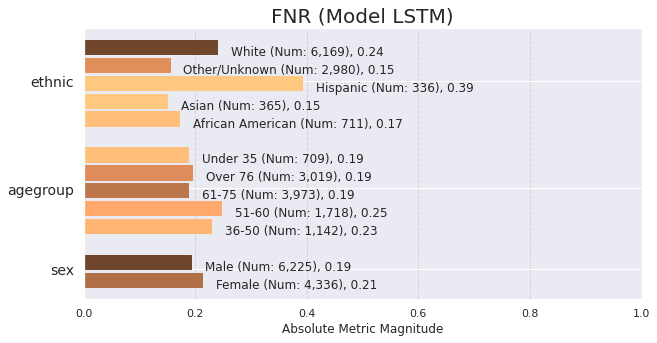

In [147]:
aqp = Plot()

a = aqp.plot_group_metric(LSTMtab, 'fnr', min_group_size=0.01)

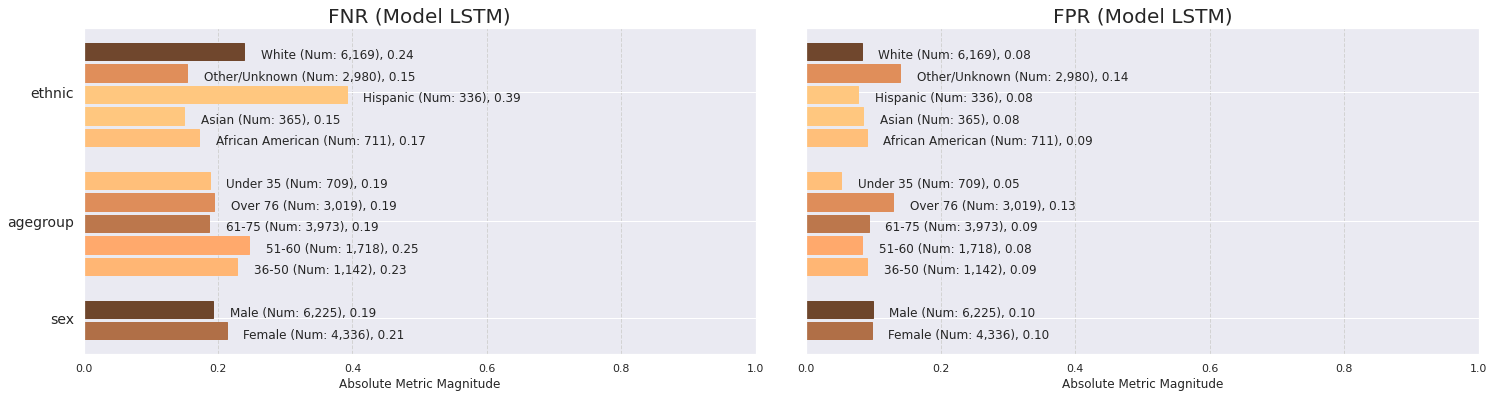

<Figure size 432x288 with 0 Axes>

In [148]:
a = aqp.plot_group_metric_all(LSTMtab, metrics=['fnr','fpr'], ncols=2, min_group_size=0.01)

In [149]:
b = Bias()

sex_ref = 'Male' 
age_ref = '61-75'
ethnic_ref = 'White' 

In [150]:
bdf = b.get_disparity_predefined_groups(LSTMtab, original_df=LSTM_df_bias, alpha=0.05, mask_significance=True,
                                        ref_groups_dict={'ethnic':ethnic_ref,'sex':sex_ref,'agegroup':age_ref})
majority_bdf = b.get_disparity_major_group(LSTMtab, original_df=LSTM_df_bias, mask_significance=True)
min_metric_bdf = b.get_disparity_min_metric(df=LSTMtab, original_df=LSTM_df_bias)
bdf.head(3)

,model_id,score_threshold,k,attribute_name,attribute_value,accuracy,tpr,tnr,for,fdr,fpr,fnr,npv,precision,pp,pn,ppr,pprev,fp,fn,tn,tp,group_label_pos,group_label_neg,group_size,total_entities,prev,ppr_disparity,pprev_disparity,precision_disparity,fdr_disparity,for_disparity,fpr_disparity,fnr_disparity,tpr_disparity,tnr_disparity,npv_disparity,ppr_ref_group_value,pprev_ref_group_value,precision_ref_group_value,fdr_ref_group_value,for_ref_group_value,fpr_ref_group_value,fnr_ref_group_value,tpr_ref_group_value,tnr_ref_group_value,npv_ref_group_value
0,LSTM,binary 0/1,1706,sex,Female,0.892758,0.787402,0.902908,0.022180,0.561404,0.097092,0.212598,0.977820,0.438596,684,3652,0.400938,0.157749,384,81,3571,300,381,3955,4336,10561,0.087869,0.669276,0.960849,0.966047,1.028234,1.039645,0.983103,1.101298,0.975767,1.001852,0.999136,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male
1,LSTM,binary 0/1,1706,sex,Male,0.892530,0.806957,0.901239,0.021334,0.545988,0.098761,0.193043,0.978666,0.454012,1022,5203,0.599062,0.164177,558,111,5092,464,575,5650,6225,10561,0.092369,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male
2,LSTM,binary 0/1,1706,agegroup,36-50,0.901051,0.771429,0.909515,0.016145,0.642384,0.090485,0.228571,0.983855,0.357616,151,991,0.088511,0.132224,97,16,975,54,70,1072,1142,10561,0.061296,0.242376,0.843221,0.776288,1.191087,0.819497,0.974869,1.222511,0.948830,1.002571,1.003628,61-75,61-75,61-75,61-75,61-75,61-75,61-75,61-75,61-75,61-75


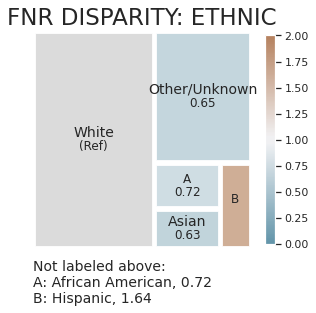

In [151]:
aqp.plot_disparity(majority_bdf, group_metric='fnr_disparity', attribute_name='ethnic', significance_alpha=0.05)

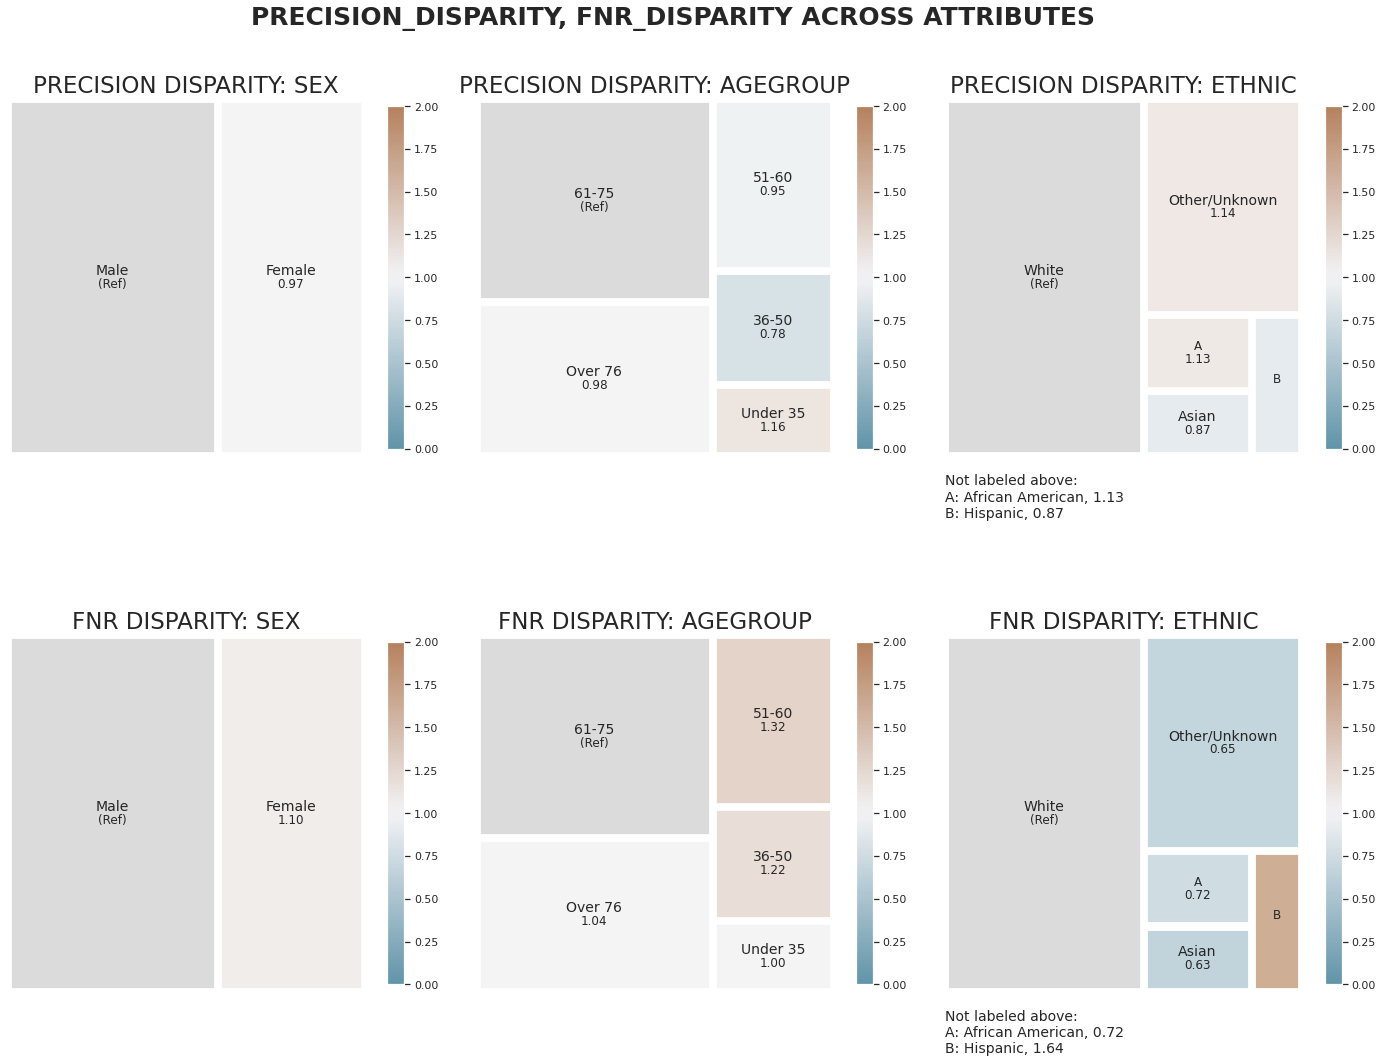

In [152]:
a = aqp.plot_disparity_all(majority_bdf, metrics=['precision_disparity', 'fnr_disparity'], significance_alpha=0.05)

In [153]:
f = Fairness()

fdf = f.get_group_value_fairness(bdf)
gaf = f.get_group_attribute_fairness(fdf)
fdf.head(3)

,model_id,score_threshold,k,attribute_name,attribute_value,accuracy,tpr,tnr,for,fdr,fpr,fnr,npv,precision,pp,pn,ppr,pprev,fp,fn,tn,tp,group_label_pos,group_label_neg,group_size,total_entities,prev,ppr_disparity,pprev_disparity,precision_disparity,fdr_disparity,for_disparity,fpr_disparity,fnr_disparity,tpr_disparity,tnr_disparity,npv_disparity,ppr_ref_group_value,pprev_ref_group_value,precision_ref_group_value,fdr_ref_group_value,for_ref_group_value,fpr_ref_group_value,fnr_ref_group_value,tpr_ref_group_value,tnr_ref_group_value,npv_ref_group_value,Statistical Parity,Impact Parity,FDR Parity,FPR Parity,FOR Parity,FNR Parity,TPR Parity,TNR Parity,NPV Parity,Precision Parity,TypeI Parity,TypeII Parity,Equalized Odds,Unsupervised Fairness,Supervised Fairness
0,LSTM,binary 0/1,1706,sex,Female,0.892758,0.787402,0.902908,0.022180,0.561404,0.097092,0.212598,0.977820,0.438596,684,3652,0.400938,0.157749,384,81,3571,300,381,3955,4336,10561,0.087869,0.669276,0.960849,0.966047,1.028234,1.039645,0.983103,1.101298,0.975767,1.001852,0.999136,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male,False,True,True,True,True,True,True,True,True,True,True,True,True,False,True
1,LSTM,binary 0/1,1706,sex,Male,0.892530,0.806957,0.901239,0.021334,0.545988,0.098761,0.193043,0.978666,0.454012,1022,5203,0.599062,0.164177,558,111,5092,464,575,5650,6225,10561,0.092369,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
2,LSTM,binary 0/1,1706,agegroup,36-50,0.901051,0.771429,0.909515,0.016145,0.642384,0.090485,0.228571,0.983855,0.357616,151,991,0.088511,0.132224,97,16,975,54,70,1072,1142,10561,0.061296,0.242376,0.843221,0.776288,1.191087,0.819497,0.974869,1.222511,0.948830,1.002571,1.003628,61-75,61-75,61-75,61-75,61-75,61-75,61-75,61-75,61-75,61-75,False,True,True,True,True,True,True,True,True,False,True,True,True,False,True


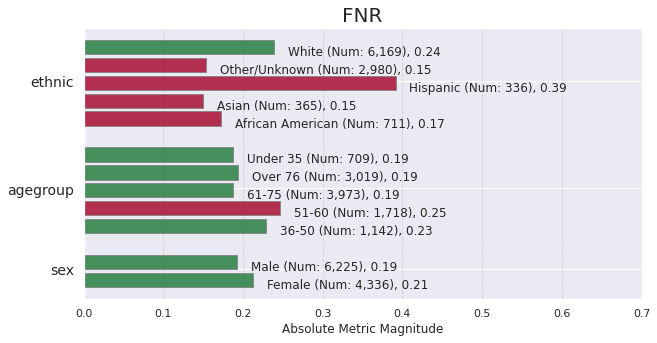

In [154]:
a = aqp.plot_fairness_group(fdf, group_metric='fnr', min_group_size=0.01, ax_lim=0.7, title=True)

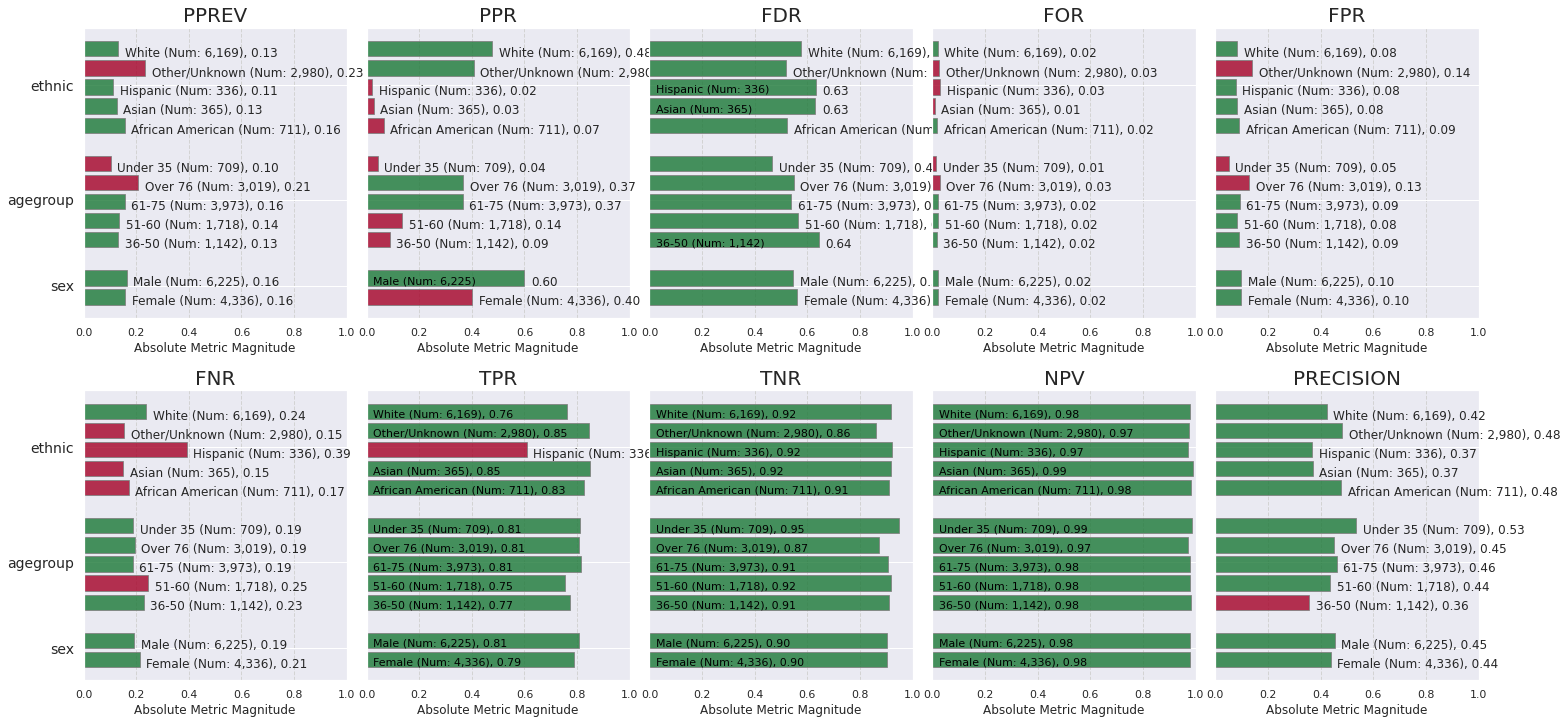

<Figure size 432x288 with 0 Axes>

In [155]:
a = aqp.plot_fairness_group_all(fdf, ncols=5, metrics = "all", min_group_size=0.01)

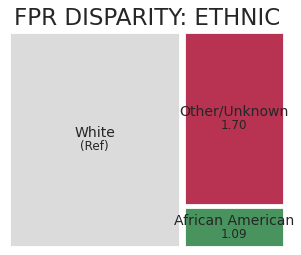

In [156]:
a = aqp.plot_fairness_disparity(fdf, group_metric='fpr', attribute_name='ethnic', min_group_size=0.02, significance_alpha=0.05)

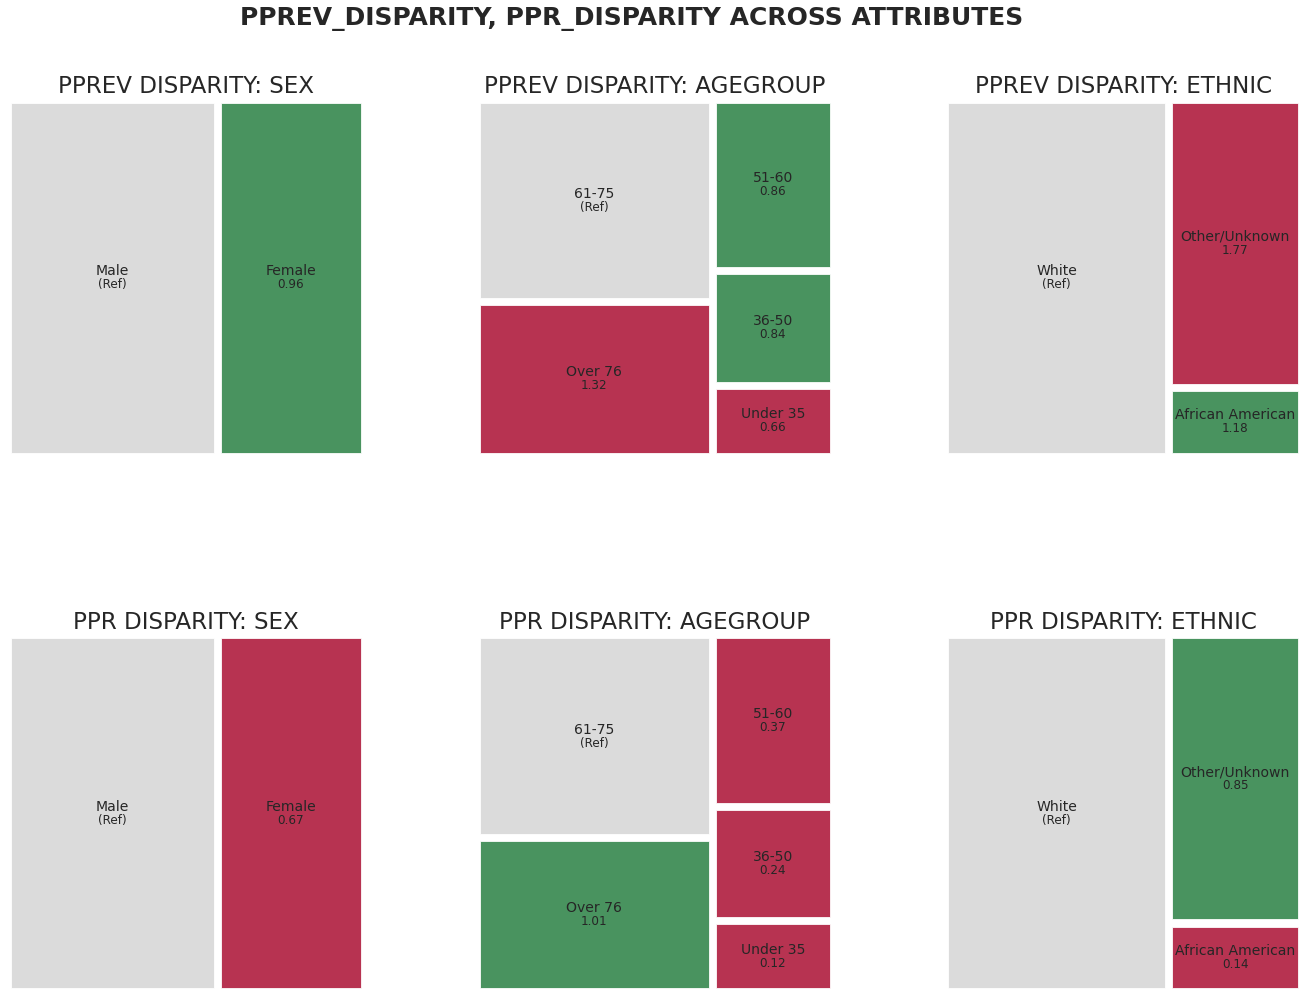

In [157]:
a = aqp.plot_fairness_disparity_all(fdf, metrics=['pprev_disparity', 'ppr_disparity'],  min_group_size=0.02, significance_alpha=0.05)

## Interpretation

### Integrated Gradients

In [49]:
def custom_eval(model):
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.eval()
        elif isinstance(module, nn.BatchNorm2d): 
            module.eval()

In [50]:
custom_eval(model) 
model.zero_grad()

In [51]:
batch_size = 1

test_loader  = DataLoader(test_dataset , batch_size=batch_size, shuffle=False, **kwargs)
test_dataloader_iter = iter(test_loader)

In [52]:
batch = next(test_dataloader_iter)

In [53]:
X, y, l = batch 
baseline = torch.zeros_like(X)

In [54]:
integrated_gradients = IntegratedGradients(model)

In [55]:
X.requires_grad_() 
baseline.requires_grad_() 

X = X.cuda()
baseline = baseline.cuda()
model.cuda()

RNN(
  (lstm): LSTM(177, 256, batch_first=True, bidirectional=True)
  (classification_head): Sequential(
    (0): Linear(in_features=512, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=32, out_features=2, bias=True)
  )
)

In [56]:
torch.backends.cudnn.enabled = False
attributions = integrated_gradients.attribute(X, baselines=baseline, target=int(y.item()), additional_forward_args=(l,))
torch.backends.cudnn.enabled = True

In [57]:
heatmap_data = attributions[0].cpu().detach().numpy()
attributions_sum = attributions[0].sum(dim=0).cpu().detach().numpy()

In [58]:
ind_features = [name for name in columns if name.endswith('_ind')]
non_ind_features = [name for name in columns if not name.endswith('_ind')]

ind_heatmap = heatmap_data[:, [columns.index(name) for name in ind_features]]
non_ind_heatmap = heatmap_data[:, [columns.index(name) for name in non_ind_features]]

ind_attributions = attributions_sum[[columns.index(name) for name in ind_features]]
non_ind_attributions = attributions_sum[[columns.index(name) for name in non_ind_features]]

In [59]:
def plot_heatmap(data, feature_names):
    
    plt.figure(figsize=(18, 10))
    
    cmap = sns.diverging_palette(250, 10, as_cmap=True)

    ax = sns.heatmap(np.array(list(reversed(data))), 
                     annot=False, fmt=".2f", cmap='coolwarm', 
                     xticklabels=feature_names, yticklabels=['Hour ' + str(i+1) for i in reversed(range(data.shape[0]))],
                     linewidths=0.5, linecolor='gray', center=0)

    ax.set_title('Attribution Heatmap', fontsize=20, pad=20)
    ax.set_xlabel('Features', fontsize=16, labelpad=10)
    ax.set_ylabel('Sequence Step', fontsize=16, labelpad=10)
    plt.xticks(rotation=45, ha='right')  
    plt.yticks(rotation=0)  
    cbar = ax.collections[0].colorbar
    cbar.set_label('Attribution', fontsize=16, labelpad=10)
    cbar.ax.tick_params(labelsize=12)
    plt.tight_layout()
    plt.show()

In [125]:
def plot_feature_attributions(data, feature_names):
    
    plt.figure(figsize=(18, 12))

    bars = plt.bar(range(len(data)), data, color='skyblue', edgecolor='blue')

    for bar in bars:
        yval = bar.get_height()
        if yval >= 0: 
            plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 2), 
                     ha='center', va='bottom', fontsize=11)
        else:
            plt.text(bar.get_x() + bar.get_width()/2, yval - 0.005, round(yval, 2), 
                     ha='center', va='bottom', fontsize=11)

    plt.xticks(range(len(data)), feature_names, rotation=45, ha="right", fontsize=14)
    
    plt.ylabel('Attribution', fontsize=16)
    plt.xlabel('Features', fontsize=16)
    plt.title('Feature Attributions', fontsize=16)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

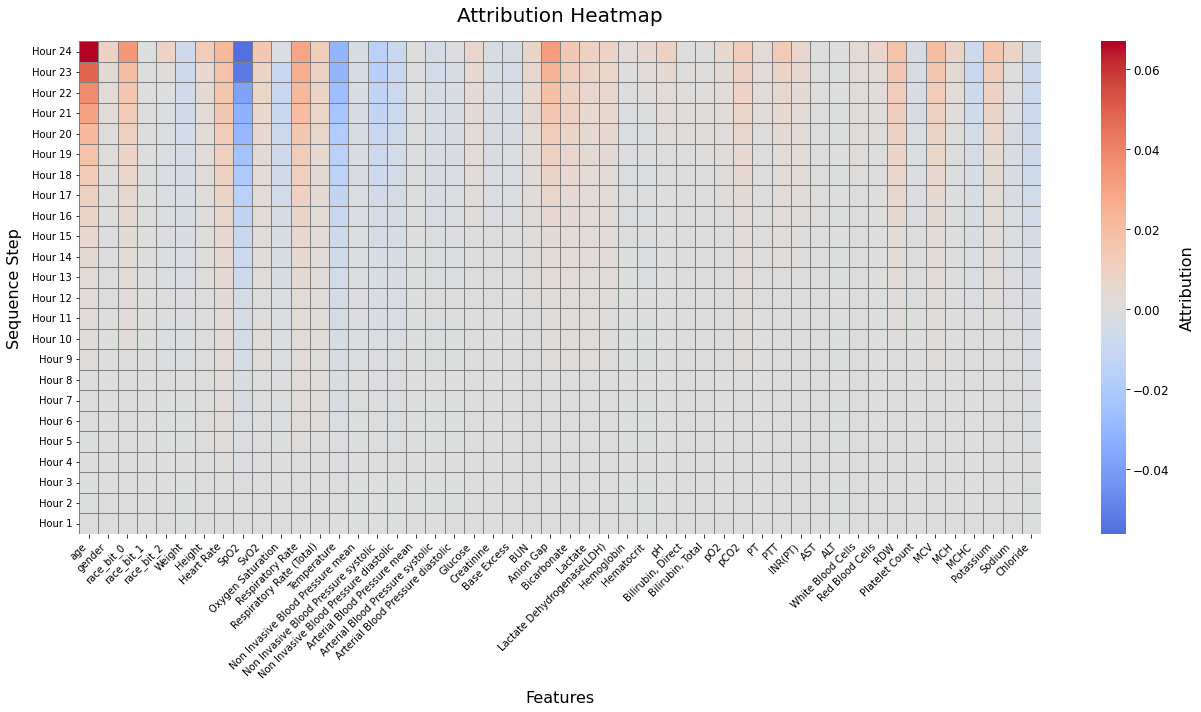

In [124]:
plot_heatmap(non_ind_heatmap[:,:50], non_ind_features[:50])

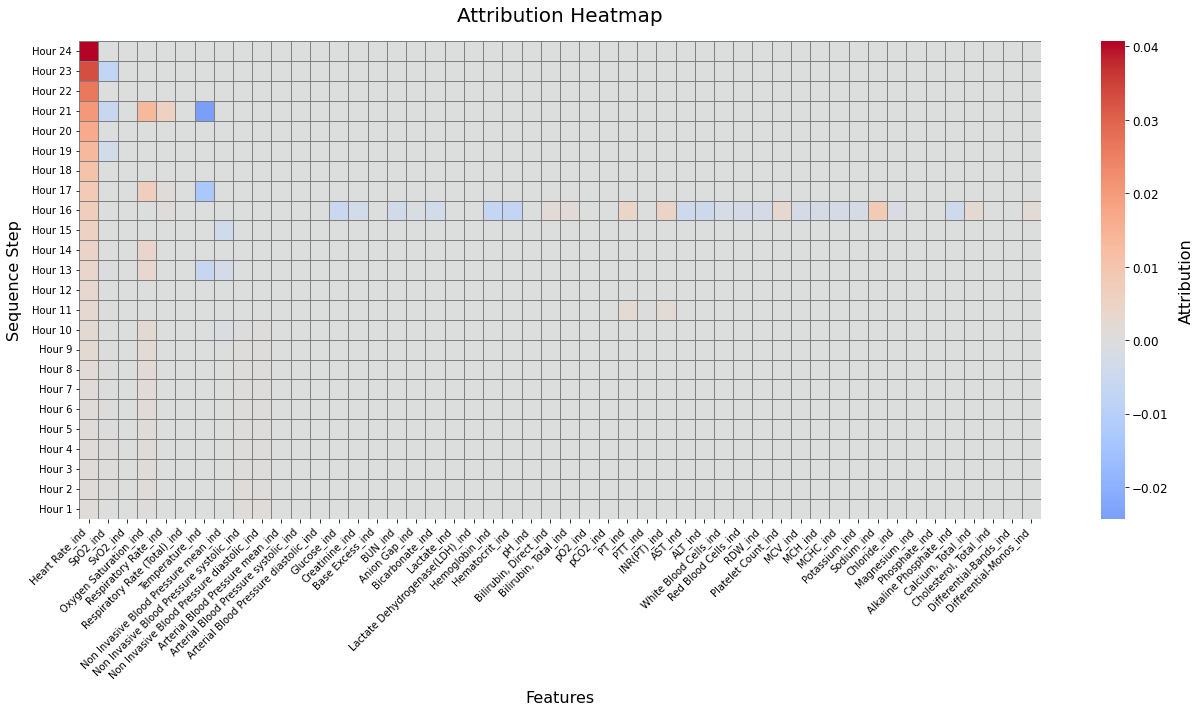

In [62]:
plot_heatmap(ind_heatmap[:,:50], ind_features[:50])

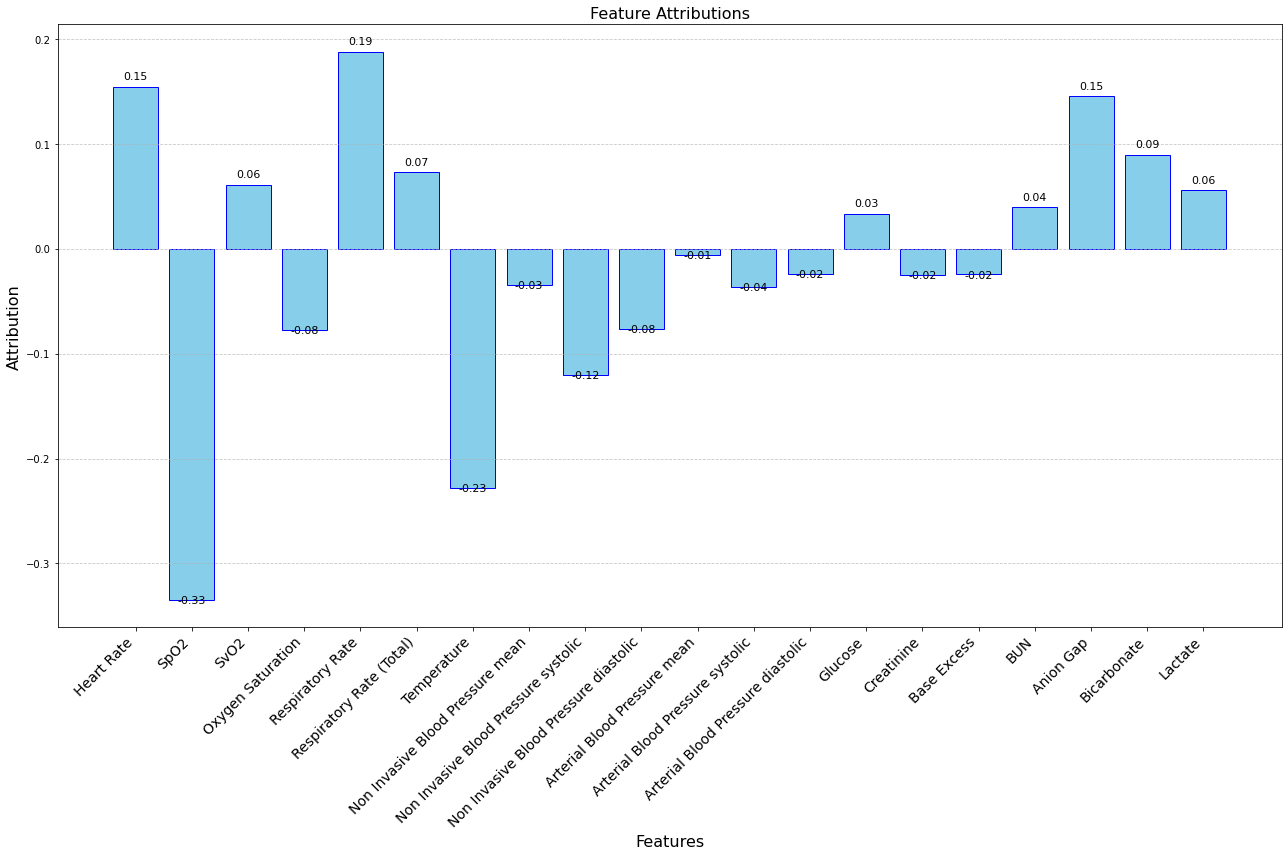

In [77]:
plot_feature_attributions(non_ind_attributions[7:27], non_ind_features[7:27])

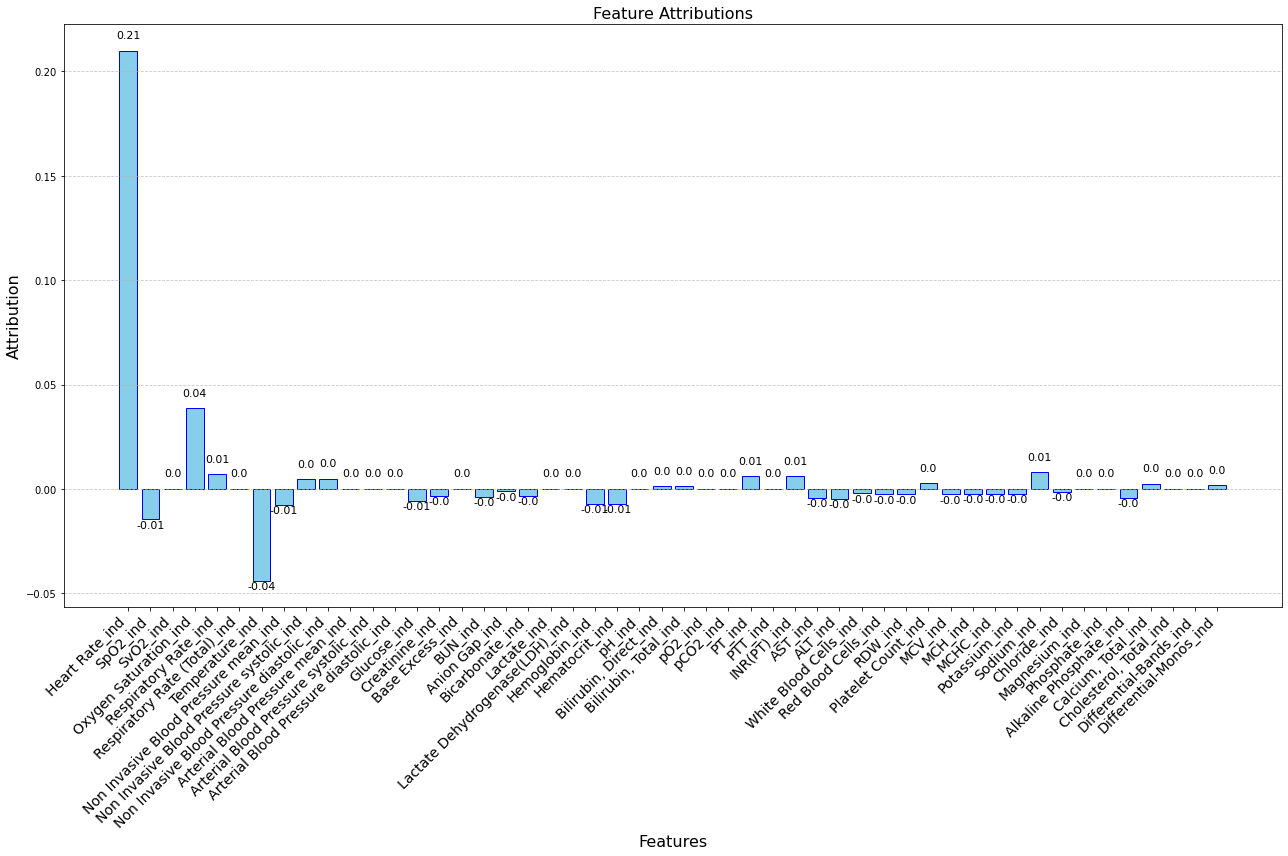

In [66]:
plot_feature_attributions(ind_attributions[:50], ind_features[:50])

### Overal Integrated Gradients

In [ ]:
custom_eval(model) 
model.zero_grad()

batch_size = 1

test_loader  = DataLoader(test_dataset , batch_size=batch_size, shuffle=False, **kwargs)
test_dataloader_iter = iter(test_loader)

all_heatmap_data = []
all_attributions_sum = []

for _ in tqdm(range(len(test_loader))):
    
    batch = next(test_dataloader_iter)
    
    X, y, l = batch 
    baseline = torch.zeros_like(X)
    
    integrated_gradients = IntegratedGradients(model)
    
    X.requires_grad_() 
    baseline.requires_grad_() 

    X = X.cuda()
    baseline = baseline.cuda()
    model.cuda()
    
    torch.backends.cudnn.enabled = False
    attributions = integrated_gradients.attribute(X, baselines=baseline, target=int(y.item()), additional_forward_args=(l,))
    torch.backends.cudnn.enabled = True
    
    heatmap_data = attributions[0].cpu().detach().numpy()
    attributions_sum = attributions[0].sum(dim=0).cpu().detach().numpy()
    
    all_heatmap_data.append(heatmap_data)
    all_attributions_sum.append(attributions_sum)

In [228]:
sum_heatmap_array = np.zeros_like(all_heatmap_data[0])

for array in all_heatmap_data:
    sum_heatmap_array += array

average_all_heatmap = sum_heatmap_array / len(all_heatmap_data)

In [229]:
sum_attributions_array = np.zeros_like(all_attributions_sum[0])

for array in all_attributions_sum:
#     sum_attributions_array += array
    sum_attributions_array += np.abs(array)

average_all_attributions = sum_attributions_array / len(all_attributions_sum)

In [230]:
ind_features = [name for name in columns if name.endswith('_ind')]
non_ind_features = [name for name in columns if not name.endswith('_ind')]

ind_heatmap = average_all_heatmap[:, [columns.index(name) for name in ind_features]]
non_ind_heatmap = average_all_heatmap[:, [columns.index(name) for name in non_ind_features]]

ind_attributions = average_all_attributions[[columns.index(name) for name in ind_features]]
non_ind_attributions = average_all_attributions[[columns.index(name) for name in non_ind_features]]

In [231]:
def order_features_and_associated_data(features, attributions, associated_data):
    """
    Orders features and their associated data based on the absolute values of their attributions.
    Args:
        features (list of str): List of feature names.
        attributions (list of float): List of attribution values corresponding to features.
        associated_data (np.ndarray): 2D numpy array with dimensions (24, len(features)).
    
    Returns:
        tuple: Ordered lists of features, their corresponding attributions, and the reordered associated data.
    """
    assert len(features) == len(attributions) == associated_data.shape[1], "Inconsistent dimensions."

    feature_attribution_indices = list(zip(features, attributions, range(len(features))))
    sorted_pairs = sorted(feature_attribution_indices, key=lambda x: abs(x[1]), reverse=True)

    ordered_features, ordered_attributions, ordered_indices = zip(*sorted_pairs)

    ordered_associated_data = associated_data[:, list(ordered_indices)]

    return list(ordered_features), list(ordered_attributions), ordered_associated_data

In [232]:
a, b, c = order_features_and_associated_data(non_ind_features, non_ind_attributions, non_ind_heatmap)

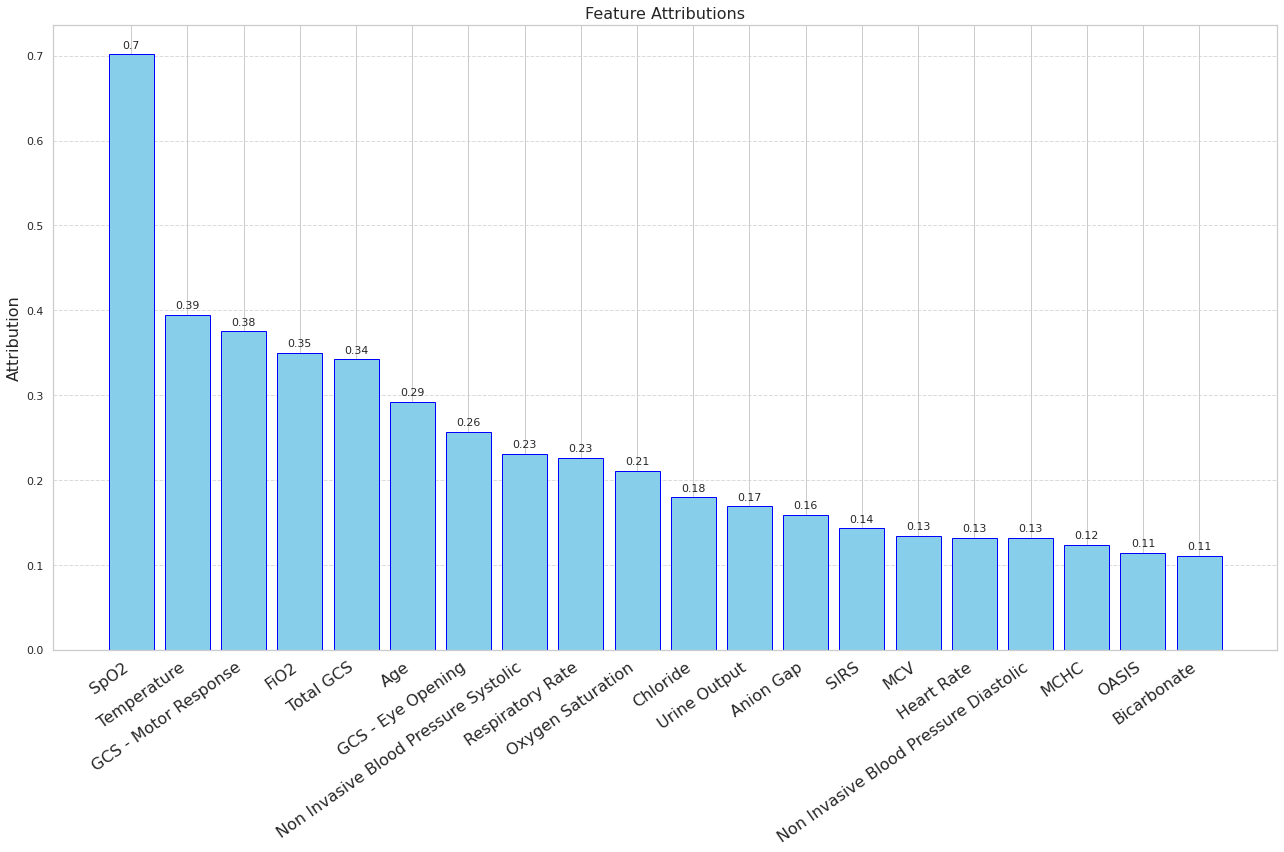

In [239]:
plot_feature_attributions(np.array(b)[:20], np.array(a)[:20])

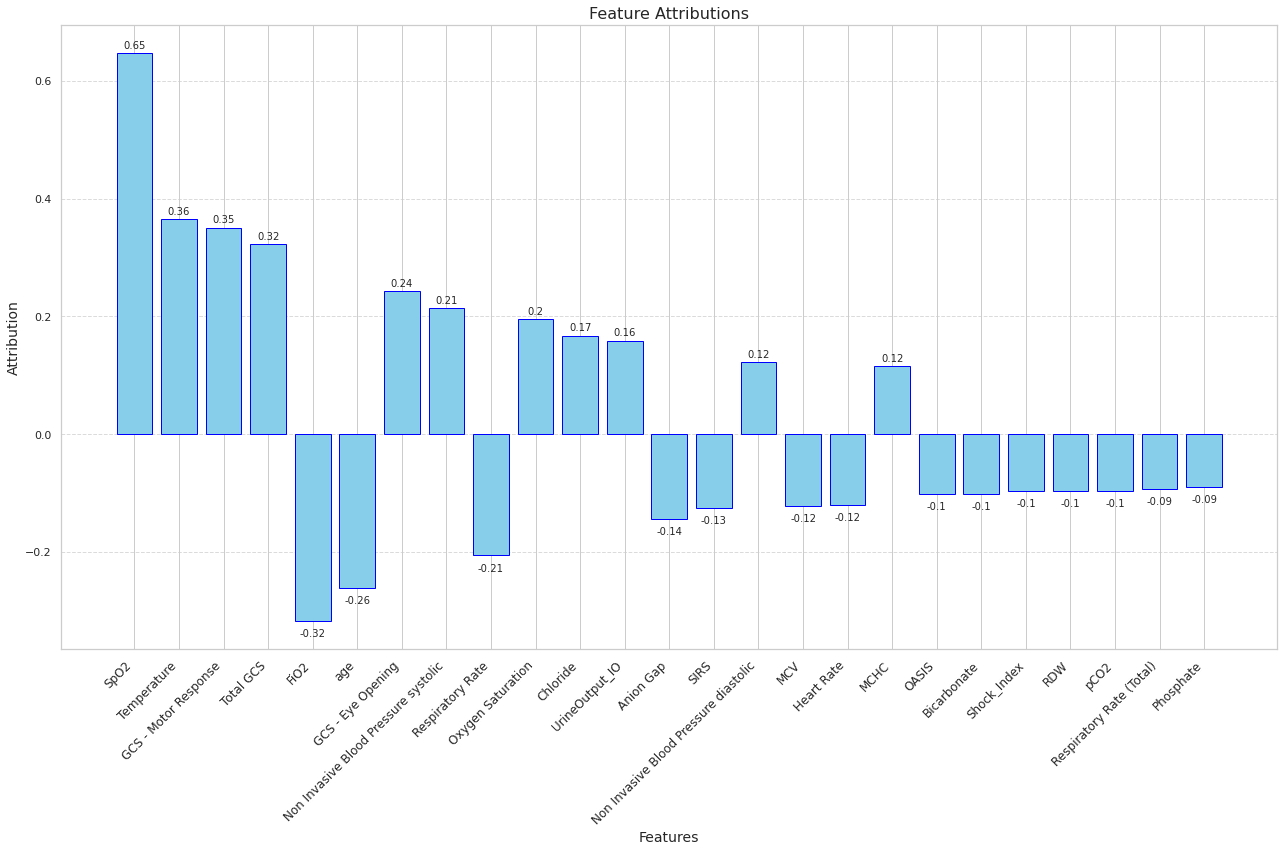

In [121]:
plot_feature_attributions(np.array(b)[:25], np.array(a)[:25])

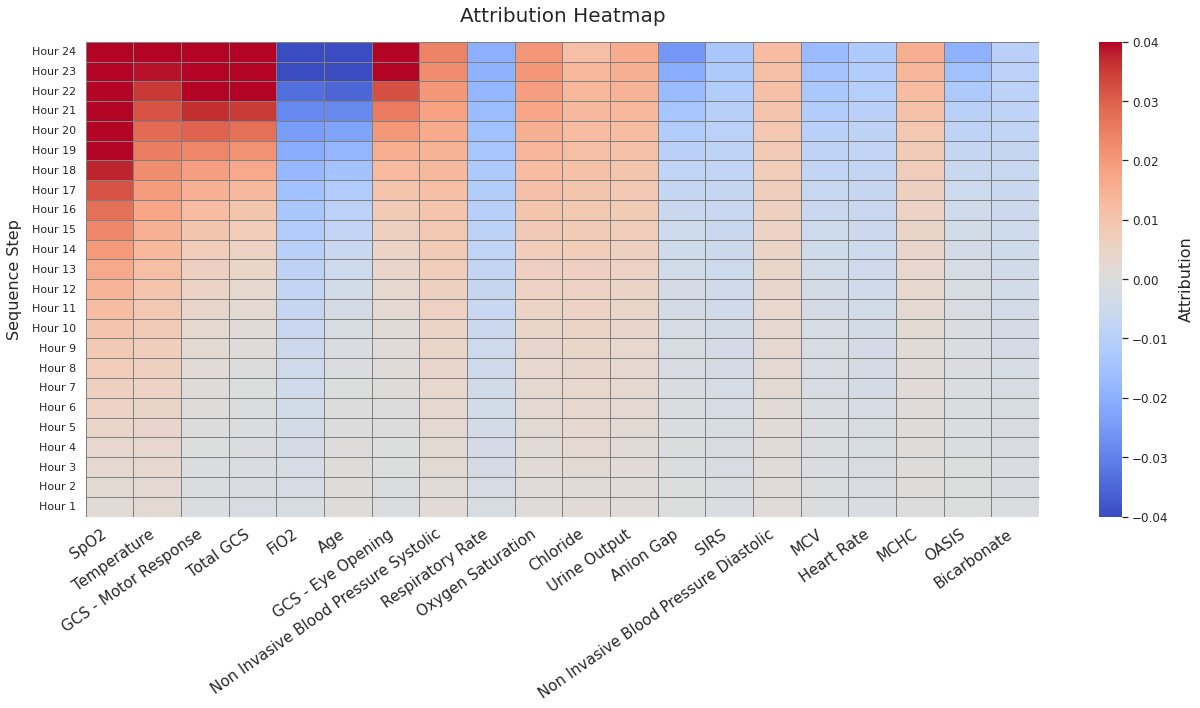

In [227]:
plot_heatmap(c[:,:20], np.array(a)[:20])

In [178]:
row_sums = np.sum(non_ind_heatmap, axis=1)

hourly_sums = {f'Hour {i+1}': abs(np.round(row_sums[i], 5)) for i in range(24)}

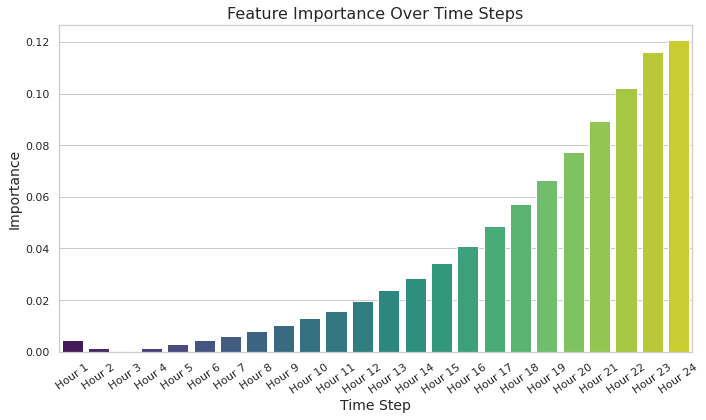

In [180]:
plot_feature_importance(hourly_sums)

### Feature Ablation 

In [129]:
batch_size = 1

test_loader  = DataLoader(test_dataset , batch_size=batch_size, shuffle=False, **kwargs)
test_dataloader_iter = iter(test_loader)

In [130]:
batch = next(test_dataloader_iter)

In [131]:
def ablate_and_predict(model, data, ablation_type='time_step', ablation_index=[]):
    
    model.eval()
    
    x, y, l = data
    
    x = x.to(device)
    y = y.to(device)
    l = l.cpu()
    y = y.long()

    seq_lengths, perm_idx = l.sort(0, descending=True) 
    x = x[perm_idx]
    y = y[perm_idx]

    with torch.no_grad():
        baseline_out = model(x, seq_lengths)
        baseline_out = nn.Softmax(dim=1)(baseline_out)
        baseline_out = baseline_out[:,1].detach().cpu().numpy()
    
    ablation_results = {}
    
    for index in ablation_index:
        
        X_ablated = x.clone()
        
        if ablation_type == 'time_step':
            X_ablated[:, index, :] = 0  
        elif ablation_type == 'feature':
            X_ablated[:, :, index] = 0  
        
    with torch.no_grad():
        ablated_out = model(X_ablated, seq_lengths)
        ablated_out = nn.Softmax(dim=1)(ablated_out)
        ablated_out = ablated_out[:,1].detach().cpu().numpy()

    ablation_results = abs(baseline_out - ablated_out)[0]  
        
    return ablation_results

In [132]:
def ablate_time_steps(model, data):

    num_time_steps = data[0].shape[1]  
    
    ablation_results = {}
    
    for time_step in range(num_time_steps):
        
        ablation_difference = ablate_and_predict(model, data, ablation_type='time_step', ablation_index=[time_step])
        ablation_results['Hour ' + str(time_step + 1)] = np.round(ablation_difference, 4)
    
    return ablation_results

In [133]:
def ablate_features(model, data, feature_names):
    
    feature_groups = {}
    for feature in feature_names:
        if '_ind' in feature:
            base_feature = feature.replace('_ind', '')
            if base_feature in feature_groups:
                feature_groups[base_feature].append(feature)
            else:
                feature_groups[base_feature] = [feature]
        else:
            feature_groups[feature] = [feature]
    
    feature_indices = {name: [feature_names.index(f) for f in group] for name, group in feature_groups.items()}
    
    ablation_results = {}
    
    for feature, indices in feature_indices.items():
        ablation_difference = ablate_and_predict(model, data, ablation_type='feature', ablation_index=indices)
        ablation_results[feature] = np.round(ablation_difference, 4)
        
    sorted_ablation_results = {k: v for k, v in sorted(ablation_results.items(), key=lambda item: item[1], reverse=True)}

    
    return sorted_ablation_results

In [134]:
def plot_feature_importance(results):
    
    time_steps = list(results.keys())
    importance_values = [results[time_step] for time_step in time_steps]
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))
    
    sns.barplot(x=time_steps, y=importance_values, palette='viridis')
    
    plt.title('Feature Importance Over Time Steps', fontsize=16)
    plt.xlabel('Time Step',  fontsize=14)
    plt.ylabel('Importance', fontsize=14)
    plt.xticks(rotation=35)
    plt.tight_layout()
    plt.show()

In [135]:
time_importance = ablate_time_steps(model, batch)
feature_importance = ablate_features(model, batch, columns)

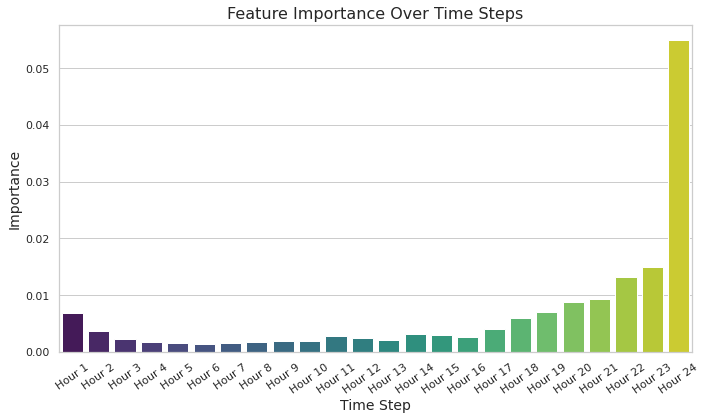

In [136]:
plot_feature_importance(time_importance)

In [137]:
number_top_features = 25

top_importance = list(feature_importance.values())[:number_top_features]
top_features = list(feature_importance.keys())[:number_top_features]

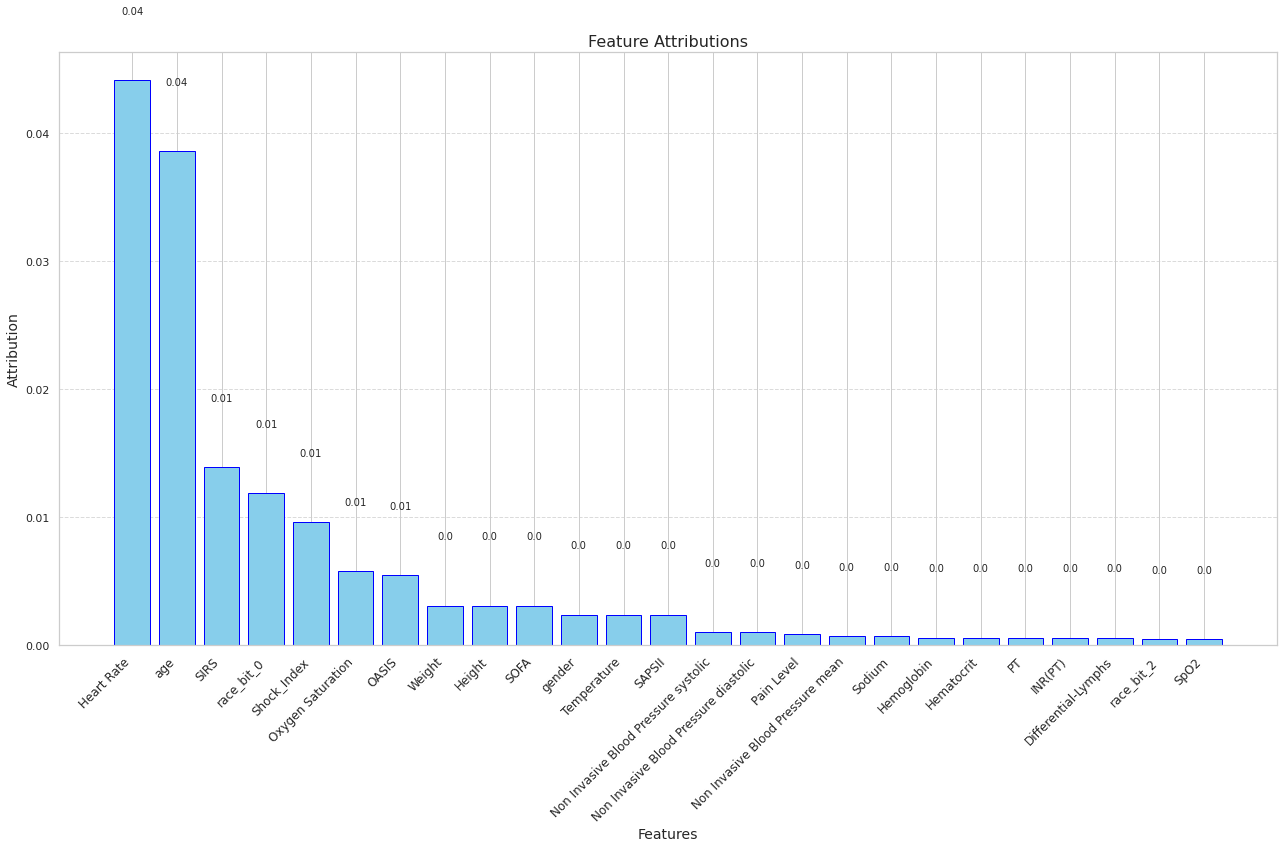

In [138]:
plot_feature_attributions(top_importance, top_features)

### Overall Feature Ablation

In [139]:
batch_size = 1

test_loader  = DataLoader(test_dataset , batch_size=batch_size, shuffle=False, **kwargs)
test_dataloader_iter = iter(test_loader)

In [140]:
all_features = []
all_timesteps = []

for _ in tqdm(range(len(test_loader))):
    
    batch = next(test_dataloader_iter)
    
    time_importance = ablate_time_steps(model, batch)
    feature_importance = ablate_features(model, batch, columns)
    
    all_timesteps.append(time_importance)
    all_features.append(feature_importance)

  0%|          | 0/132779 [00:00<?, ?it/s]

In [252]:
# with open("./all_timesteps", "wb") as fp:  
#     pickle.dump(all_timesteps, fp)
    
# with open("./all_features", "wb") as fp:  
#     pickle.dump(all_features, fp)

In [253]:
# with open("./all_timesteps", "rb") as fp:   
#     a = pickle.load(fp)
    
# with open("./all_features", "rb") as fp:   
#     b = pickle.load(fp)

In [143]:
time_sums = defaultdict(float)
time_counts = defaultdict(int)

feature_sums = defaultdict(float)
feature_counts = defaultdict(int)

In [144]:
for record in all_timesteps:
    for time, importance in record.items():
        time_sums[time] += importance
        time_counts[time] += 1

In [145]:
for record in all_features:
    for feature, importance in record.items():
        feature_sums[feature] += importance
        feature_counts[feature] += 1

In [146]:
average_time_importance = {time: np.round(time_sums[time] / time_counts[time], 3) for time in time_sums}
average_feature_importance = {feature: np.round(feature_sums[feature] / feature_counts[feature], 3) for feature in feature_sums}
sorted_feature_results = {k: v for k, v in sorted(average_feature_importance.items(), key=lambda item: item[1], reverse=True)}

In [154]:
number_top_features = 22

top_importance = list(sorted_feature_results.values())[:number_top_features]
top_features = list(sorted_feature_results.keys())[:number_top_features]

In [163]:
new_top_features = []
new_top_importance = []

for i in range(len(top_features)):
    if top_features[i] not in ['race_bit_0', 'race_bit_1', 'race_bit_2']:
        new_top_features.append(top_features[i])
        new_top_importance.append(top_importance[i])

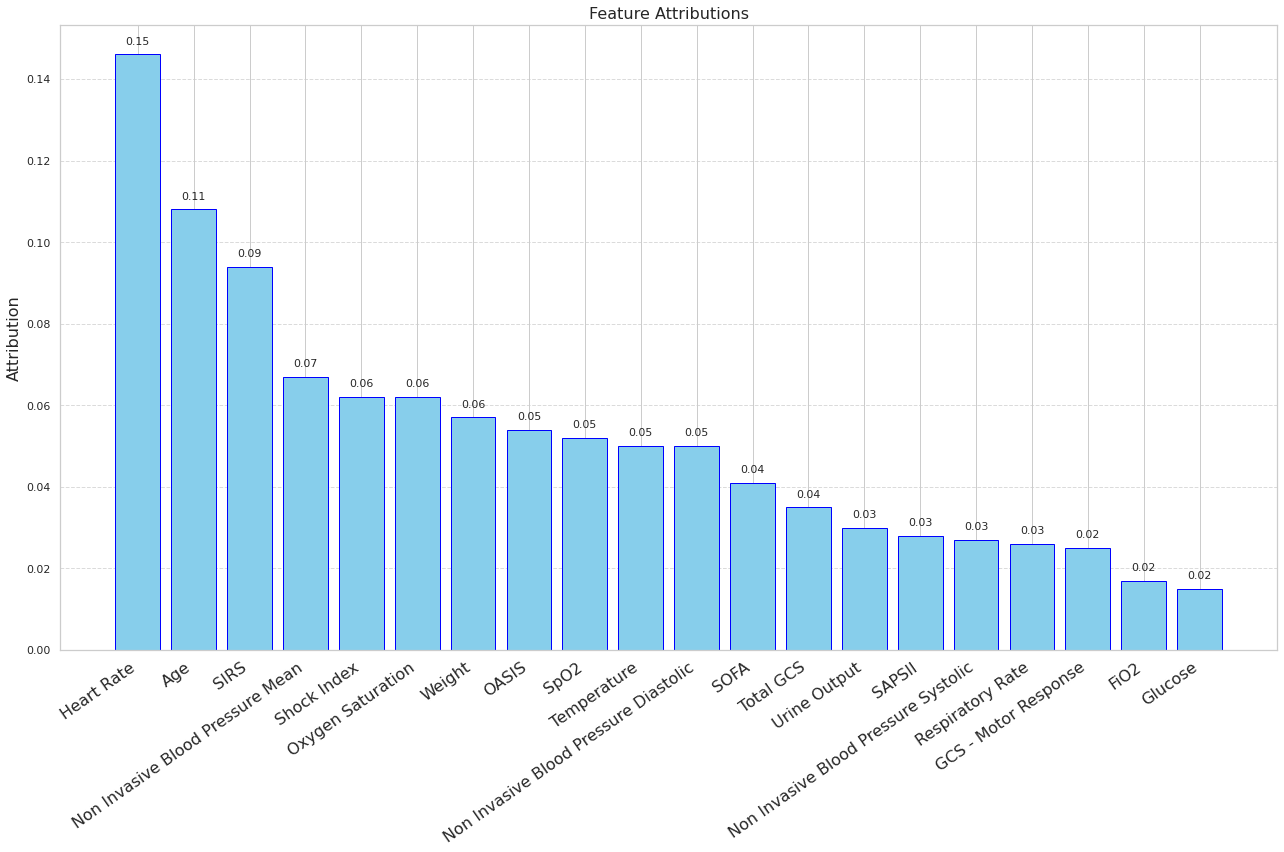

In [249]:
plot_feature_attributions(new_top_importance, new_top_features)

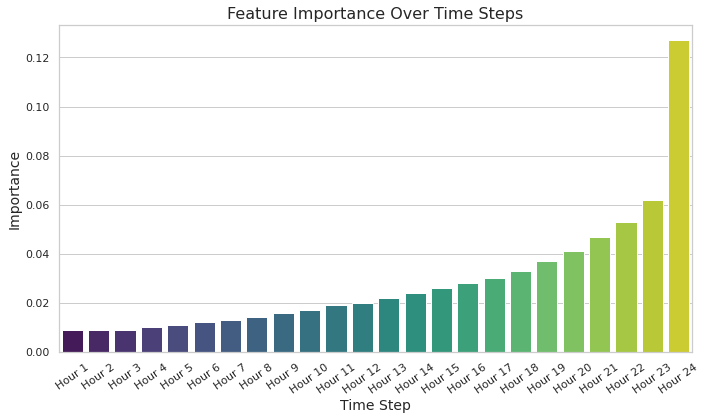

In [149]:
plot_feature_importance(average_time_importance)